<img
  src="Ibmec_logo.png"
  alt="A cabeça e o tronco de um esqueleto de dinossauro;
          tem uma cabeça grande com dentes longos e afiados"
  width="400"
  height="341" />
# Programação para Análise de Dados
## Aula 1: Introdução à Análise de Dados. Etapas do processo de extração e preparação de dados 
### Prof. Carlos Eduardo Leal de Castro

## Análise exploratória de dados (AED)

- Verificar os dados para qualquer aplicação estatística.
- Entendimento sobre os dados coletados
- Obter relações existentes entre as variáveis analisadas
- Fazer análises e previsões a partir disso.

**Quadro 1.** Abordagens estatísticas e estratégias utilizadas

| **Abordagem**            | **Estratégia**                                      |
|--------------------------|-----------------------------------------------------|
| Estatística clássica     | Problema → Dados → Modelo → Análise                 |
| Estatística bayesiana    | Problema → Dados → Modelo Priori → Análise          |
| AED                      | Problema → Dados → Análise → Modelo                 |

A Análise de Dados é o processo sistemático de:
1.  **Coletar (Extrair)**
2.  **Limpar (Preparar)**
3.  **Transformar**
4.  **Analisar e Modelar**

...dados para extrair **insights valiosos** que direcionam decisões inteligentes, seja na otimização de uma linha de produção, na previsão de demanda ou na compreensão do mercado.

Um projeto de dados segue um fluxo de trabalho bem definido, conhecido como **pipeline**.

<img src="https://miro.medium.com/v2/resize:fit:523/1*52H6P5vG0HY6JNuPYmlQ3A.png" width="700"/>


## Classificação de dados

- Os dados são considerados como variáveis;
- **Valores numéricos**:  valores quantitativos, podem ser representados de duas formas
    - valores inteiros (discretos)
    -  intervalo de números reais (contínuos)
- **Valores não-numéricos**: valores qualitativos,podem ser tratados como valores nominais
    - Para categorias de valores ordenados, se tem o tipo de valor **qualitativo ordinal**.

## Etapas de uma análise exploratória de dados

<img src="diagrama.png" width="1800"/>


## Coleta e organização de dados

Na etapa de coleta de dados, deve-se definir quais serão os métodos de coleta utilizados.

- São definidos os objetivos, ou seja, as questões da pesquisa; 
- Define-se quais dados serão coletados e como serão coletados.

## Coleta e organização de dados

A organização dos dados consiste em estabelecer como obter informações a partir dos dados coletados a respeito de uma ou mais características de interesse. 

**É muito importante levar em consideração a natureza dos dados (data de nascimento $\Rightarrow$ Dia | Mês | Ano).**


## Tratamento de dados

A etapa de tratamento dos dados visa a melhorar ou adequar o conjunto de dados obtidos.
- **Imputação de dados**
    -  o dado pode ser substituído por um valor, como a média ou a repetição do último valor, ou por uma regressão linear.
- **Normalização**
    - transformar um conjunto de dados que estão em diferentes grandezas e escalas em um conjunto de dados padronizados.

## Tratamento de dados
- **Outlier**
    - uma observação que está muito distante do padrão observado naquele conjunto de dados, e pode ser causado por entrada errada de dados ou erros em tempo de tratamento.
    - existem diversos métodos para detecção de outlier (Amplitude Interquartil, IsolationForest, ...)

## Análise de dados

- A análise univariada consiste em avaliar cada uma das variáveis isoladamente.
    - Por exemplo, calcular a média, mediana, moda e criar gráficos
- A análise multivariada estabelece relações entre duas ou mais variáveis.
    - Por exemplo, a altura da pessoa mediante o sexo e a idade

## Apresentação e Interpretação de dados

Existem duas formas de apresentar os dados:

- A apresentação tabular é a representação usando uma tabela, que deve ter alguns elementos essenciais, como título da tabela, títulos das colunas e corpo com o conjunto dos dados. 

- A representação gráfica deve ser autoexplicativa e de fácil compreen-são. Existem diferentes tipos de gráficos para cada uma das variáveis que se quer representar, a exemplo dos gráficos de colunas, barras, linhas, setores, entre outros.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Configuração para gráficos mais bonitos
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Criando um dataset fictício de indicadores econômicos
np.random.seed(42)

# Gerando dados para 1000 empresas fictícias
n_empresas = 1000

data = {
    'receita_anual': np.random.lognormal(mean=15, sigma=1.2, size=n_empresas),
    'lucro_liquido': np.random.normal(loc=50000, scale=25000, size=n_empresas),
    'num_funcionarios': np.random.poisson(lam=150, size=n_empresas),
    'margem_lucro': np.random.beta(a=2, b=5, size=n_empresas) * 100,
    'anos_mercado': np.random.exponential(scale=8, size=n_empresas),
    'investimento_rd': np.random.gamma(shape=2, scale=10000, size=n_empresas)
}

# Criando DataFrame
df = pd.DataFrame(data)

# Ajustando alguns valores para tornar mais realista
df['receita_anual'] = df['receita_anual'].round(0)
df['lucro_liquido'] = df['lucro_liquido'].round(0)
df['margem_lucro'] = df['margem_lucro'].round(2)
df['anos_mercado'] = df['anos_mercado'].round(1)
df['investimento_rd'] = df['investimento_rd'].round(0)

In [2]:
def ex1():
    print("="*60)
    print("ANÁLISE UNIVARIADA - INDICADORES ECONÔMICOS")
    print("="*60)

    # 1. VISÃO GERAL DOS DADOS
    print("\n1. INFORMAÇÕES GERAIS DO DATASET")
    print("-" * 40)
    print(f"Número de empresas analisadas: {len(df)}")
    print(f"Número de variáveis: {df.shape[1]}")
    print("\nPrimeiras 5 observações:")
    print(df.head())

In [3]:
ex1()

ANÁLISE UNIVARIADA - INDICADORES ECONÔMICOS

1. INFORMAÇÕES GERAIS DO DATASET
----------------------------------------
Número de empresas analisadas: 1000
Número de variáveis: 6

Primeiras 5 observações:
   receita_anual  lucro_liquido  num_funcionarios  margem_lucro  anos_mercado  \
0      5933098.0        84984.0               147         28.18           2.7   
1      2769238.0        73116.0               144         15.39           2.8   
2      7111518.0        51491.0               151         14.86           2.8   
3     20330562.0        33827.0               128         58.90          10.3   
4      2468240.0        67456.0               161         48.43           2.1   

   investimento_rd  
0          23587.0  
1          13682.0  
2          28073.0  
3           1753.0  
4          10254.0  


In [4]:
# 2. ESTATÍSTICAS DESCRITIVAS
print("\n\n2. ESTATÍSTICAS DESCRITIVAS - OI")
print("-" * 40)
desc_stats = df.describe()
print(desc_stats.round(2))



2. ESTATÍSTICAS DESCRITIVAS - OI
----------------------------------------
       receita_anual  lucro_liquido  num_funcionarios  margem_lucro  \
count   1.000000e+03        1000.00           1000.00       1000.00   
mean    6.938875e+06       51770.90            149.88         29.41   
std     1.460804e+07       24936.37             12.04         16.27   
min     6.686800e+04      -23510.00            116.00          0.54   
25%     1.502880e+06       34843.75            141.00         16.70   
50%     3.369790e+06       51577.00            150.00         27.81   
75%     7.113698e+06       68222.25            158.00         40.84   
max     3.328751e+08      129828.00            189.00         75.35   

       anos_mercado  investimento_rd  
count       1000.00          1000.00  
mean           7.78         20579.35  
std            7.77         13744.28  
min            0.00           231.00  
25%            2.20         10525.00  
50%            5.40         17726.50  
75%        

In [5]:
# Função para análise individual de cada variável
def analisar_variavel(variavel, titulo, unidade=""):
    print(f"\n\n3. ANÁLISE DETALHADA - {titulo.upper()}")
    print("-" * 50)
    
    # Estatísticas básicas
    dados = df[variavel]
    print(f"Média: {dados.mean():.2f} {unidade}")
    print(f"Mediana: {dados.median():.2f} {unidade}")
    print(f"Desvio Padrão: {dados.std():.2f} {unidade}")
    print(f"Coeficiente de Variação: {(dados.std()/dados.mean())*100:.2f}%")
    print(f"Assimetria: {dados.skew():.2f}")
    print(f"Curtose: {dados.kurtosis():.2f}")
    
    # Quartis
    q1, q3 = dados.quantile(0.25), dados.quantile(0.75)
    iqr = q3 - q1
    print(f"\nQ1 (25%): {q1:.2f} {unidade}")
    print(f"Q3 (75%): {q3:.2f} {unidade}")
    print(f"IQR: {iqr:.2f} {unidade}")
    
    # Outliers
    limite_inf = q1 - 1.5 * iqr
    limite_sup = q3 + 1.5 * iqr
    outliers = dados[(dados < limite_inf) | (dados > limite_sup)]
    print(f"Número de outliers: {len(outliers)} ({len(outliers)/len(dados)*100:.1f}%)")


In [6]:
# Análise da variável principal: Receita Anual
analisar_variavel('receita_anual', 'Receita Anual', 'R$')



3. ANÁLISE DETALHADA - RECEITA ANUAL
--------------------------------------------------
Média: 6938874.79 R$
Mediana: 3369790.50 R$
Desvio Padrão: 14608040.25 R$
Coeficiente de Variação: 210.52%
Assimetria: 12.78
Curtose: 255.77

Q1 (25%): 1502880.25 R$
Q3 (75%): 7113698.25 R$
IQR: 5610818.00 R$
Número de outliers: 101 (10.1%)


In [7]:
def graficos1():
    # 4. CRIANDO GRÁFICOS BONITOS
    print("\n\n4. GERANDO VISUALIZAÇÕES...")
    print("-" * 40)

    # Configuração da figura com múltiplos subplots
    fig = plt.figure(figsize=(20, 15))
    fig.suptitle('Análise Univariada - Indicadores Econômicos', fontsize=20, fontweight='bold', y=0.98)

    # 1. Histograma da Receita Anual
    ax1 = plt.subplot(2, 2, 1)
    plt.hist(df['receita_anual'], bins=50, alpha=0.7, color='skyblue', edgecolor='black', linewidth=0.5)
    plt.axvline(df['receita_anual'].mean(), color='red', linestyle='--', linewidth=2, label=f'Média: R$ {df["receita_anual"].mean():,.0f}')
    plt.axvline(df['receita_anual'].median(), color='orange', linestyle='--', linewidth=2, label=f'Mediana: R$ {df["receita_anual"].median():,.0f}')
    plt.title('Distribuição da Receita Anual', fontsize=14, fontweight='bold')
    plt.xlabel('Receita Anual (R$)')
    plt.ylabel('Frequência')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # 2. Boxplot da Margem de Lucro
    ax2 = plt.subplot(2, 2, 2)
    box_plot = plt.boxplot(df['margem_lucro'], patch_artist=True, labels=['Margem de Lucro'])
    box_plot['boxes'][0].set_facecolor('lightgreen')
    box_plot['boxes'][0].set_alpha(0.7)
    plt.title('Boxplot - Margem de Lucro', fontsize=14, fontweight='bold')
    plt.ylabel('Margem de Lucro (%)')
    plt.grid(True, alpha=0.3)




4. GERANDO VISUALIZAÇÕES...
----------------------------------------


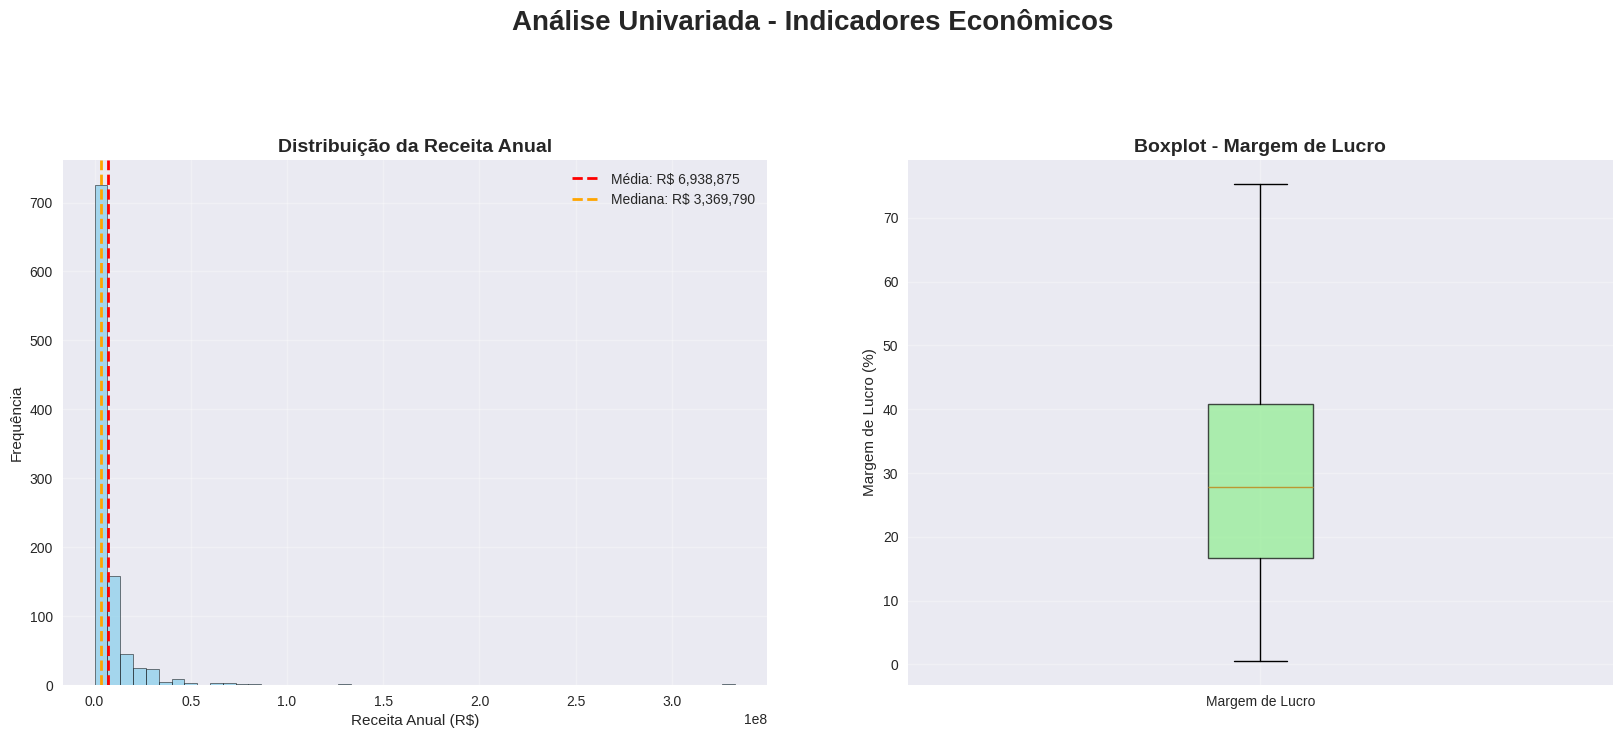

In [8]:
graficos1()

In [9]:
def graficos2():
    # 4. CRIANDO GRÁFICOS BONITOS
    print("\n\n4. GERANDO VISUALIZAÇÕES...")
    print("-" * 40)

    # Configuração da figura com múltiplos subplots
    fig = plt.figure(figsize=(20, 15))
    fig.suptitle('Análise Univariada - Indicadores Econômicos', fontsize=20, fontweight='bold', y=0.98)

    # 3. Densidade do Número de Funcionários
    ax3 = plt.subplot(2, 2, 1)
    df['num_funcionarios'].plot(kind='density', color='purple', alpha=0.7, linewidth=2)
    plt.fill_between(df['num_funcionarios'].plot(kind='density').get_lines()[0].get_xdata(),
                    df['num_funcionarios'].plot(kind='density').get_lines()[0].get_ydata(), 
                    alpha=0.3, color='purple')
    plt.title('Densidade - Número de Funcionários', fontsize=14, fontweight='bold')
    plt.xlabel('Número de Funcionários')
    plt.ylabel('Densidade')
    plt.grid(True, alpha=0.3)

    # 4. Q-Q Plot para normalidade da receita
    ax4 = plt.subplot(2, 2, 2)
    stats.probplot(df['receita_anual'], dist="norm", plot=plt)
    plt.title('Q-Q Plot - Receita Anual', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)




4. GERANDO VISUALIZAÇÕES...
----------------------------------------


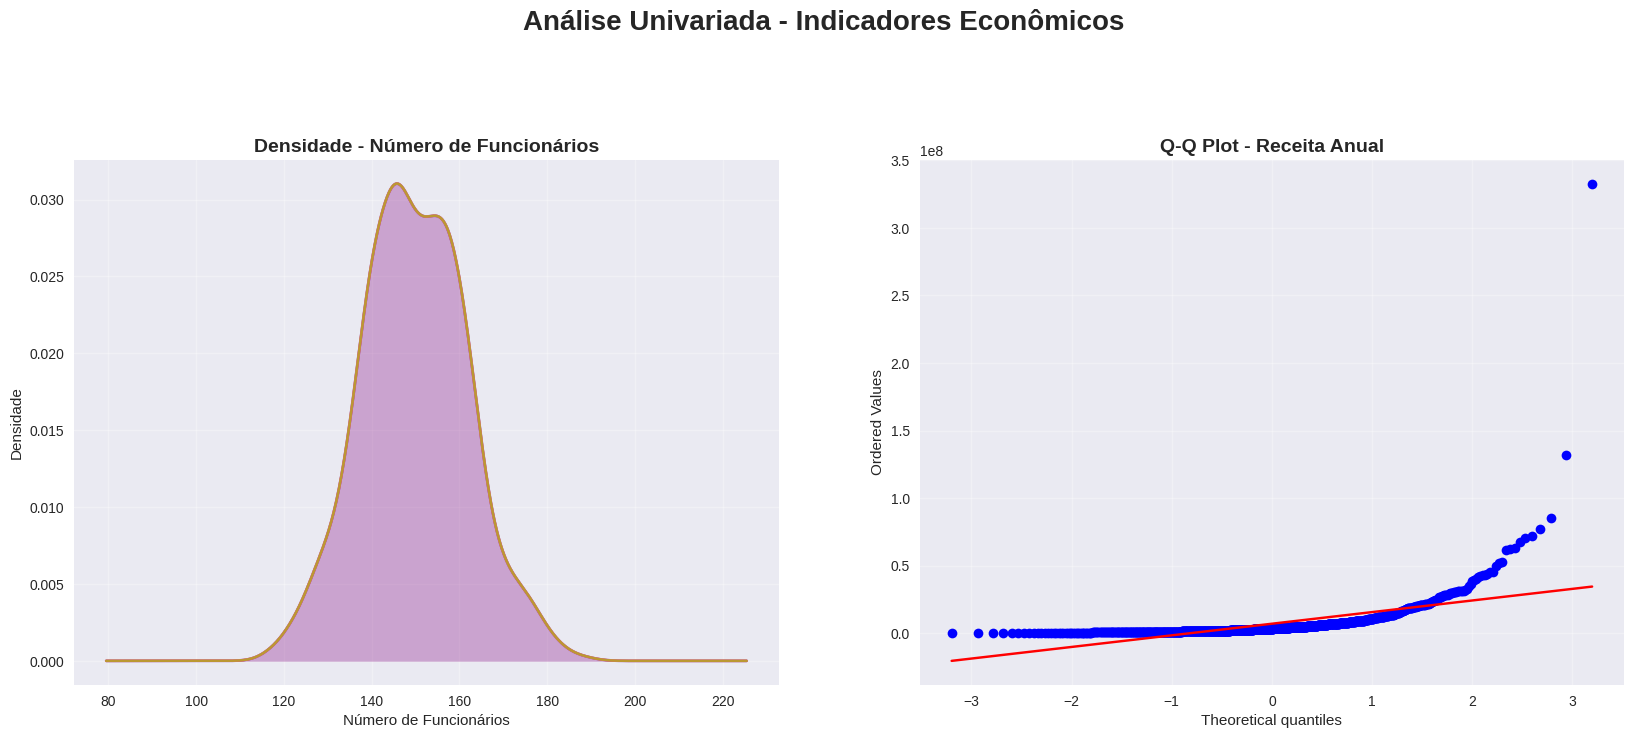

In [10]:
graficos2()

In [11]:
def graficos3():
    # 4. CRIANDO GRÁFICOS BONITOS
    print("\n\n4. GERANDO VISUALIZAÇÕES...")
    print("-" * 40)

    # Configuração da figura com múltiplos subplots
    fig = plt.figure(figsize=(20, 15))
    fig.suptitle('Análise Univariada - Indicadores Econômicos', fontsize=20, fontweight='bold', y=0.98)


    # 5. Histograma dos Anos no Mercado
    ax5 = plt.subplot(2, 2, 1)
    plt.hist(df['anos_mercado'], bins=30, alpha=0.7, color='coral', edgecolor='black', linewidth=0.5)
    plt.axvline(df['anos_mercado'].mean(), color='darkred', linestyle='--', linewidth=2, 
               label=f'Média: {df["anos_mercado"].mean():.1f} anos')
    plt.title('Distribuição - Anos no Mercado', fontsize=14, fontweight='bold')
    plt.xlabel('Anos no Mercado')
    plt.ylabel('Frequência')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # 6. Boxplot do Investimento em P&D
    ax6 = plt.subplot(2, 2, 2)
    box_plot2 = plt.boxplot(df['investimento_rd'], patch_artist=True, labels=['Investimento P&D'])
    box_plot2['boxes'][0].set_facecolor('gold')
    box_plot2['boxes'][0].set_alpha(0.7)
    plt.title('Boxplot - Investimento em P&D', fontsize=14, fontweight='bold')
    plt.ylabel('Investimento P&D (R$)')
    plt.grid(True, alpha=0.3)



4. GERANDO VISUALIZAÇÕES...
----------------------------------------


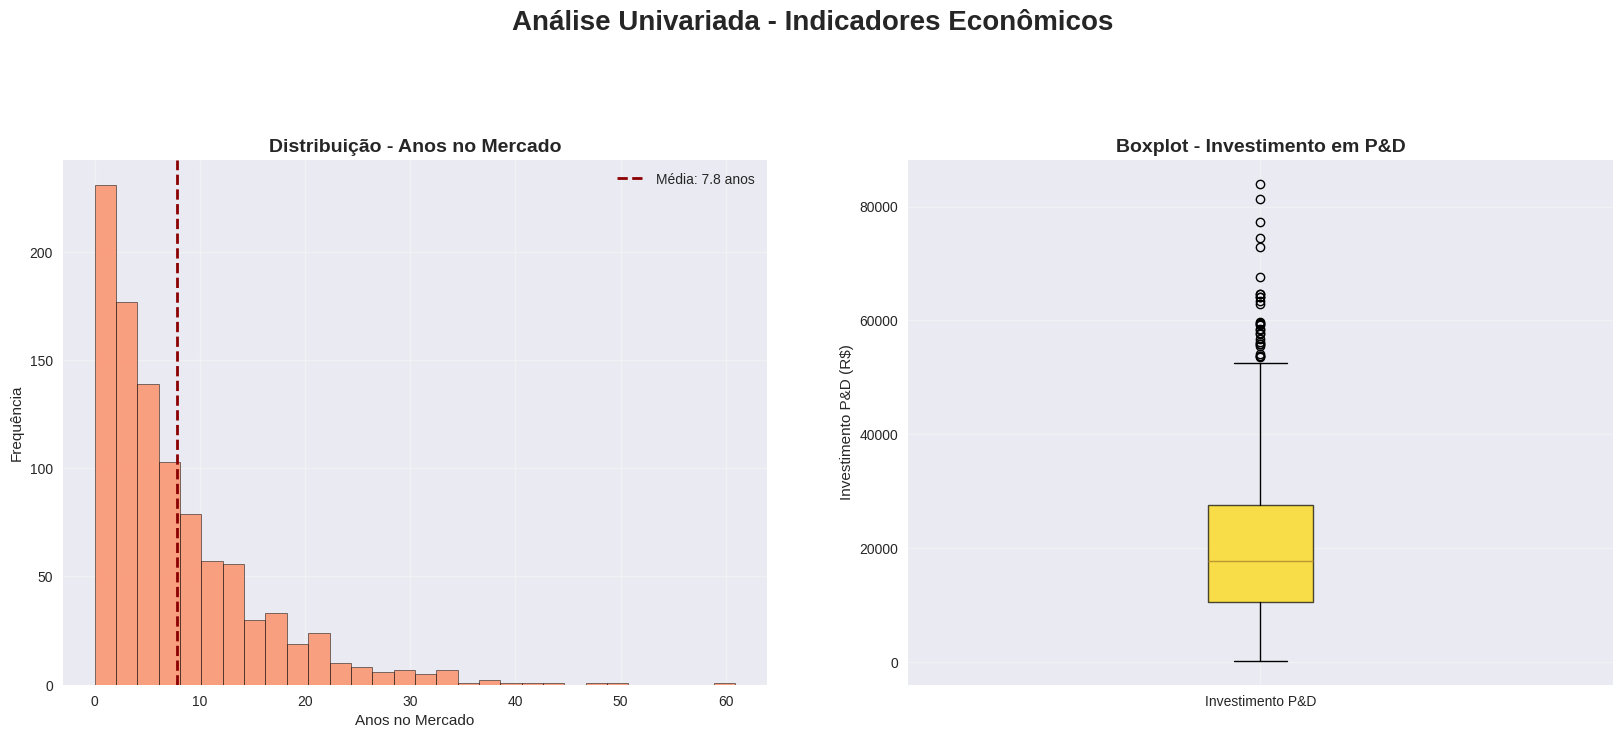

In [12]:
graficos3()

In [13]:
def graficos4():
    # 4. CRIANDO GRÁFICOS BONITOS
    print("\n\n4. GERANDO VISUALIZAÇÕES...")
    print("-" * 40)

    # Configuração da figura com múltiplos subplots
    fig = plt.figure(figsize=(20, 15))
    fig.suptitle('Análise Univariada - Indicadores Econômicos', fontsize=20, fontweight='bold', y=0.98)


    # 7. Gráfico de barras - Estatísticas resumo da Receita
#     ax7 = plt.subplot(2, 2, 7)
    stats_receita = ['Mínimo', 'Q1', 'Mediana', 'Média', 'Q3', 'Máximo']
    valores_receita = [df['receita_anual'].min(), df['receita_anual'].quantile(0.25), 
                       df['receita_anual'].median(), df['receita_anual'].mean(),
                       df['receita_anual'].quantile(0.75), df['receita_anual'].max()]
    bars = plt.bar(stats_receita, valores_receita, color=['red', 'orange', 'yellow', 'green', 'blue', 'purple'], alpha=0.7)
    plt.title('Estatísticas Resumo - Receita Anual', fontsize=14, fontweight='bold')
    plt.ylabel('Receita (R$)')
    plt.xticks(rotation=45)
    # Adicionando valores nas barras
    for bar, valor in zip(bars, valores_receita):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(valores_receita)*0.01, 
                 f'R$ {valor:,.0f}', ha='center', va='bottom', fontsize=8)
    plt.grid(True, alpha=0.3)



4. GERANDO VISUALIZAÇÕES...
----------------------------------------


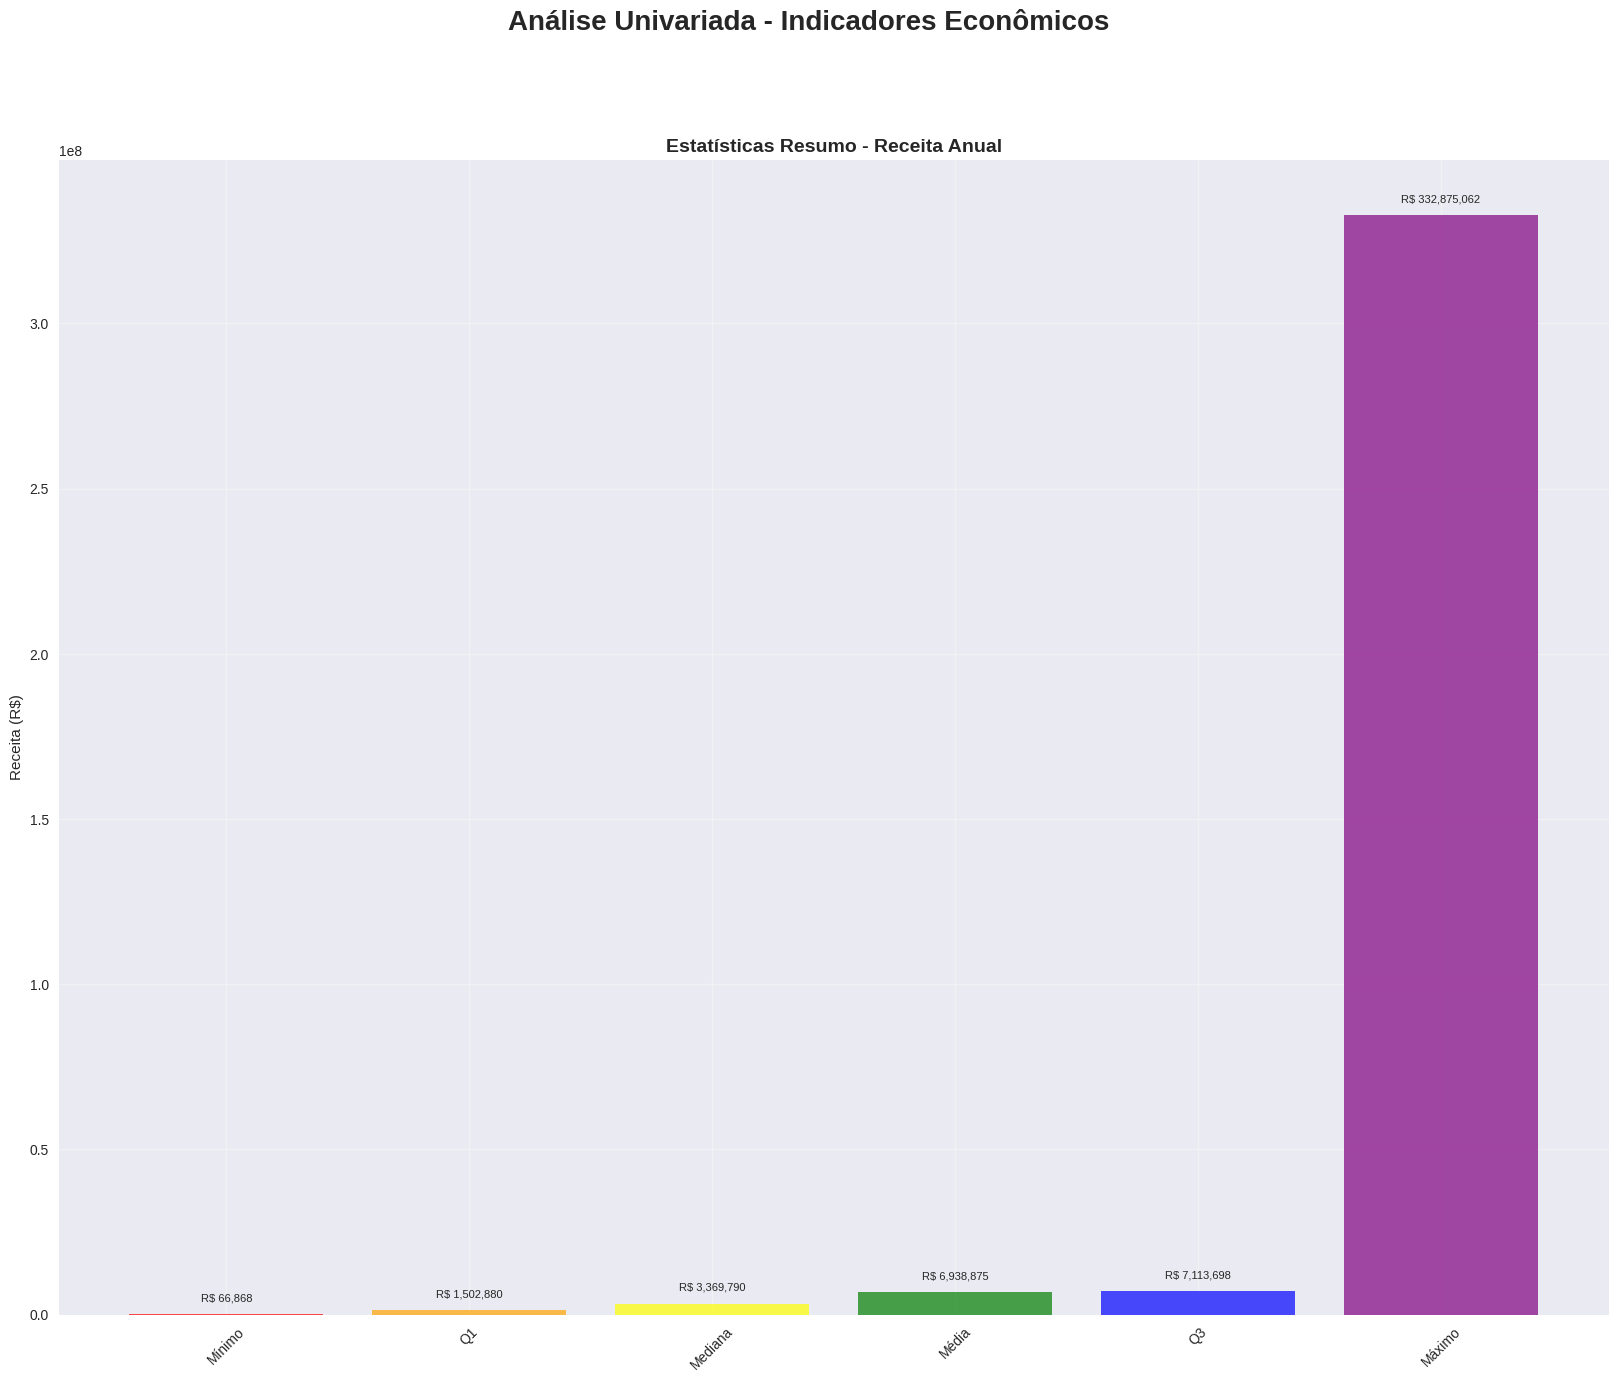

In [14]:
graficos4()

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Configuração para gráficos mais bonitos
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.facecolor'] = 'white'

# Criando dataset mais robusto para análise multivariada
np.random.seed(42)
n_empresas = 1000

# Gerando dados correlacionados de forma mais realista
# Base de receita
receita_base = np.random.lognormal(mean=15, sigma=1.2, size=n_empresas)

# Variáveis correlacionadas com receita
num_funcionarios = 50 + (receita_base / 100000) * 80 + np.random.normal(0, 30, n_empresas)
num_funcionarios = np.maximum(num_funcionarios, 10)  # Mínimo de 10 funcionários

# Lucro correlacionado com receita e número de funcionários
lucro_liquido = (receita_base * 0.15) + (num_funcionarios * 500) + np.random.normal(0, 15000, n_empresas)

# Margem de lucro inversamente correlacionada com tamanho
margem_lucro = np.maximum(2, 25 - (receita_base / 1000000) * 5 + np.random.normal(0, 3, n_empresas))

# Anos no mercado correlacionado com receita e estabilidade
anos_mercado = np.maximum(1, np.log(receita_base / 100000) * 3 + np.random.exponential(5, n_empresas))

# Investimento P&D correlacionado com receita e margem
investimento_rd = (receita_base * 0.05) + (margem_lucro * 1000) + np.random.gamma(2, 5000, n_empresas)

# Criando variáveis categóricas
setor = np.random.choice(['Tecnologia', 'Varejo', 'Serviços', 'Indústria', 'Energia'], 
                        size=n_empresas, p=[0.3, 0.2, 0.2, 0.2, 0.1])

porte = np.where(num_funcionarios < 50, 'Pequeno',
                np.where(num_funcionarios < 200, 'Médio', 'Grande'))

# DataFrame final
data = {
    'receita_anual': receita_base.round(0),
    'lucro_liquido': lucro_liquido.round(0),
    'num_funcionarios': num_funcionarios.round(0).astype(int),
    'margem_lucro': margem_lucro.round(2),
    'anos_mercado': anos_mercado.round(1),
    'investimento_rd': investimento_rd.round(0),
    'setor': setor,
    'porte': porte
}

df = pd.DataFrame(data)

# Separando variáveis numéricas
numeric_cols = ['receita_anual', 'lucro_liquido', 'num_funcionarios', 
                'margem_lucro', 'anos_mercado', 'investimento_rd']
df_numeric = df[numeric_cols]

In [16]:
def amv():
    print("="*70)
    print("ANÁLISE MULTIVARIADA - INDICADORES ECONÔMICOS")
    print("="*70)

    print("\n1. VISÃO GERAL DOS DADOS")
    print("-" * 50)
    print(f"Dimensões do dataset: {df.shape}")
    print("\nPrimeiras observações:")
    print(df.head())

In [17]:
amv()

ANÁLISE MULTIVARIADA - INDICADORES ECONÔMICOS

1. VISÃO GERAL DOS DADOS
--------------------------------------------------
Dimensões do dataset: (1000, 8)

Primeiras observações:
   receita_anual  lucro_liquido  num_funcionarios  margem_lucro  anos_mercado  \
0      5933098.0      3299066.0              4838          2.00          15.6   
1      2769238.0      1559783.0              2293          8.57          10.4   
2      7111518.0      3925343.0              5741          2.00          30.8   
3     20330562.0     11192486.0             16295          2.00          19.6   
4      2468240.0      1364601.0              2046         14.33          14.4   

   investimento_rd       setor   porte  
0         306056.0      Varejo  Grande  
1         149582.0    Serviços  Grande  
2         369458.0  Tecnologia  Grande  
3        1019549.0    Serviços  Grande  
4         149794.0   Indústria  Grande  


In [18]:
print("\nDistribuição por setor:")
print(df['setor'].value_counts())

print("\nDistribuição por porte:")
print(df['porte'].value_counts())


Distribuição por setor:
setor
Tecnologia    288
Varejo        216
Serviços      213
Indústria     191
Energia        92
Name: count, dtype: int64

Distribuição por porte:
porte
Grande    994
Médio       6
Name: count, dtype: int64


In [19]:
# Correlação de Pearson
corr_pearson = df_numeric.corr()

# Identificando correlações mais fortes
correlacoes_fortes = []
for i in range(len(corr_pearson.columns)):
    for j in range(i+1, len(corr_pearson.columns)):
        corr_val = corr_pearson.iloc[i, j]
        if abs(corr_val) > 0.5:
            correlacoes_fortes.append({
                'var1': corr_pearson.columns[i],
                'var2': corr_pearson.columns[j],
                'correlacao': corr_val
            })

In [20]:
print(f"Correlações fortes (|r| > 0.5):")
for item in sorted(correlacoes_fortes, key=lambda x: abs(x['correlacao']), reverse=True):
    print(f"  {item['var1']} ↔ {item['var2']}: r = {item['correlacao']:.3f}")

Correlações fortes (|r| > 0.5):
  lucro_liquido ↔ num_funcionarios: r = 1.000
  receita_anual ↔ num_funcionarios: r = 1.000
  receita_anual ↔ lucro_liquido: r = 1.000
  receita_anual ↔ investimento_rd: r = 1.000
  num_funcionarios ↔ investimento_rd: r = 1.000
  lucro_liquido ↔ investimento_rd: r = 1.000


In [21]:
# Padronizando os dados
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_numeric)

# Aplicando PCA
pca = PCA()
pca_result = pca.fit_transform(df_scaled)

# Variância explicada
variancia_explicada = pca.explained_variance_ratio_
variancia_acumulada = np.cumsum(variancia_explicada)

# Componentes principais
components_df = pd.DataFrame(
    pca.components_[:3],  # Primeiros 3 componentes
    columns=numeric_cols,
    index=[f'PC{i+1}' for i in range(3)]
)

# Determinando número ótimo de clusters (método do cotovelo)
inertias = []
K_range = range(2, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inertias.append(kmeans.inertia_)

# Aplicando K-means com 4 clusters
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
clusters = kmeans.fit_predict(df_scaled)
df['cluster'] = clusters

for i in range(n_clusters):
    cluster_size = (clusters == i).sum()

# Caracterização dos clusters
cluster_stats = df.groupby('cluster')[numeric_cols].mean()

# Modelo para prever receita anual
X = df[['lucro_liquido', 'num_funcionarios', 'margem_lucro', 'anos_mercado', 'investimento_rd']]
y = df['receita_anual']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Treinando modelo
modelo = LinearRegression()
modelo.fit(X_train, y_train)

# Predições
y_pred_train = modelo.predict(X_train)
y_pred_test = modelo.predict(X_test)

# Métricas
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
mae_test = mean_absolute_error(y_test, y_pred_test)

coef_df = pd.DataFrame({
    'Variável': X.columns,
    'Coeficiente': modelo.coef_,
    'Importância': np.abs(modelo.coef_) / np.sum(np.abs(modelo.coef_)) * 100
}).sort_values('Importância', ascending=False)

In [27]:
def imgs(ni):
    # 6. VISUALIZAÇÕES AVANÇADAS
    print("\n\n6. GERANDO VISUALIZAÇÕES MULTIVARIADAS...")
    print("-" * 50)

    # Criando figura com múltiplos subplots
    fig = plt.figure(figsize=(24, 10))
    fig.suptitle('Análise Multivariada - Indicadores Econômicos', fontsize=24, fontweight='bold', y=0.98)

    if ni == 1:
        # 1. Heatmap de Correlações
        ax1 = plt.subplot(1, 2, 1)
        mask = np.triu(np.ones_like(corr_pearson, dtype=bool))
        sns.heatmap(corr_pearson, mask=mask, annot=True, cmap='RdYlBu_r', center=0,
                    square=True, linewidths=0.5, cbar_kws={"shrink": .8}, fmt='.2f')
        plt.title('Matriz de Correlações', fontsize=14, fontweight='bold')

        # 2. Scatterplot Matrix (pairplot simplificado)
        ax2 = plt.subplot(1, 2, 2)
        principais_vars = ['receita_anual', 'lucro_liquido', 'num_funcionarios', 'margem_lucro']
        scatter_colors = ['red', 'blue', 'green', 'orange']
        for i, var1 in enumerate(principais_vars[:2]):
            for j, var2 in enumerate(principais_vars[2:]):
                if i == 0 and j == 0:  # Apenas um scatter para não poluir
                    plt.scatter(df[var1], df[var2], alpha=0.6, c=df['cluster'], 
                               cmap='viridis', s=20)
                    plt.xlabel(var1.replace('_', ' ').title())
                    plt.ylabel(var2.replace('_', ' ').title())
        plt.title('Receita vs Funcionários (colorido por cluster)', fontsize=14, fontweight='bold')
        plt.colorbar(label='Cluster')
    elif ni == 2:
        # 3. Biplot PCA
        ax1 = plt.subplot(1, 2, 1)
        # Scatter dos dados transformados
        scatter = plt.scatter(pca_result[:, 0], pca_result[:, 1], 
                             c=df['cluster'], cmap='viridis', alpha=0.6, s=20)
        # Vetores das variáveis originais
        scale_factor = 3
        for i, (var, pc1, pc2) in enumerate(zip(numeric_cols, 
                                               pca.components_[0], 
                                               pca.components_[1])):
            plt.arrow(0, 0, pc1*scale_factor, pc2*scale_factor, 
                      head_width=0.1, head_length=0.1, fc='red', ec='red', alpha=0.8)
            plt.text(pc1*scale_factor*1.1, pc2*scale_factor*1.1, var.replace('_', '\n'), 
                     fontsize=8, ha='center', va='center')
        plt.xlabel(f'PC1 ({variancia_explicada[0]*100:.1f}% var.)')
        plt.ylabel(f'PC2 ({variancia_explicada[1]*100:.1f}% var.)')
        plt.title('Biplot PCA', fontsize=14, fontweight='bold')
        plt.grid(True, alpha=0.3)

        # 4. Variância Explicada PCA
        ax2 = plt.subplot(1, 2, 2)
        plt.bar(range(1, len(variancia_explicada)+1), variancia_explicada, 
                alpha=0.7, color='steelblue', label='Individual')
        plt.plot(range(1, len(variancia_acumulada)+1), variancia_acumulada, 
                 'ro-', linewidth=2, label='Acumulada')
        plt.xlabel('Componente Principal')
        plt.ylabel('Variância Explicada')
        plt.title('Variância Explicada - PCA', fontsize=14, fontweight='bold')
        plt.legend()
        plt.grid(True, alpha=0.3)
    elif ni == 3:
        # 5. Análise de Clusters - Scatter 3D simulado
        ax1 = plt.subplot(1, 2, 1)
        scatter = plt.scatter(df['receita_anual'], df['lucro_liquido'], 
                             c=df['cluster'], cmap='tab10', s=30, alpha=0.7)
        plt.xlabel('Receita Anual')
        plt.ylabel('Lucro Líquido')
        plt.title('Clusters - Receita vs Lucro', fontsize=14, fontweight='bold')
        plt.colorbar(scatter, label='Cluster')

        # 6. Método do Cotovelo
        ax2 = plt.subplot(1, 2, 2)
        plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
        plt.xlabel('Número de Clusters (k)')
        plt.ylabel('Inércia')
        plt.title('Método do Cotovelo', fontsize=14, fontweight='bold')
        plt.grid(True, alpha=0.3)
        # Destacar o ponto escolhido
        optimal_k = 4
        optimal_idx = optimal_k - 2  # Ajuste do índice
        plt.scatter(optimal_k, inertias[optimal_idx], color='red', s=100, 
                   label=f'k={optimal_k} (escolhido)')
        plt.legend()
    elif ni == 4:
        # 7. Boxplot por Setor
        ax1 = plt.subplot(1, 2, 1)
        df.boxplot(column='receita_anual', by='setor', ax=ax1)
        plt.title('Receita por Setor', fontsize=14, fontweight='bold')
        plt.suptitle('')  # Remove título automático do pandas
        plt.xticks(rotation=45)
        plt.ylabel('Receita Anual')

        # 8. Heatmap Clusters vs Setores
        ax2 = plt.subplot(1, 2, 2)
        cluster_setor = pd.crosstab(df['cluster'], df['setor'], normalize='index') * 100
        sns.heatmap(cluster_setor, annot=True, fmt='.1f', cmap='YlOrRd', 
                    cbar_kws={'label': '% dentro do cluster'})
        plt.title('Distribuição Setor por Cluster (%)', fontsize=14, fontweight='bold')
        plt.ylabel('Cluster')
    elif ni == 5:
        # 9. Regressão - Valores Reais vs Preditos
        ax1 = plt.subplot(1, 2, 1)
        plt.scatter(y_test, y_pred_test, alpha=0.6, color='blue')
        plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
        plt.xlabel('Receita Real')
        plt.ylabel('Receita Predita')
        plt.title(f'Regressão: R² = {r2_test:.3f}', fontsize=14, fontweight='bold')
        plt.grid(True, alpha=0.3)

        # 10. Importância das Variáveis no Modelo
        ax2 = plt.subplot(1, 2, 2)
        coef_df_plot = coef_df.sort_values('Importância')
        bars = plt.barh(coef_df_plot['Variável'], coef_df_plot['Importância'], 
                        color='skyblue', alpha=0.8)
        plt.xlabel('Importância (%)')
        plt.title('Importância das Variáveis', fontsize=14, fontweight='bold')
        plt.grid(True, alpha=0.3, axis='x')
    elif ni == 6:
        # 11. Distribuição por Porte
        ax1 = plt.subplot(1, 2, 1)
        porte_counts = df['porte'].value_counts()
        colors = ['gold', 'lightcoral', 'lightblue']
        wedges, texts, autotexts = plt.pie(porte_counts.values, labels=porte_counts.index, 
                                          autopct='%1.1f%%', colors=colors, startangle=90)
        plt.title('Distribuição por Porte', fontsize=14, fontweight='bold')

        # 12. Correlação Receita vs Investimento P&D por Setor
        ax2 = plt.subplot(1, 2, 2)
        setores_cores = {'Tecnologia': 'red', 'Varejo': 'blue', 'Serviços': 'green', 
                        'Indústria': 'orange', 'Energia': 'purple'}
        for setor in df['setor'].unique():
            setor_data = df[df['setor'] == setor]
            plt.scatter(setor_data['investimento_rd'], setor_data['receita_anual'], 
                       label=setor, alpha=0.6, color=setores_cores.get(setor, 'black'))
        plt.xlabel('Investimento P&D')
        plt.ylabel('Receita Anual')
        plt.title('Receita vs P&D por Setor', fontsize=14, fontweight='bold')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True, alpha=0.3)
    elif ni == 7:
        # 13. Análise de Resíduos
        ax1 = plt.subplot(1, 2, 1)
        residuos = y_test - y_pred_test
        plt.scatter(y_pred_test, residuos, alpha=0.6)
        plt.axhline(y=0, color='red', linestyle='--')
        plt.xlabel('Valores Preditos')
        plt.ylabel('Resíduos')
        plt.title('Análise de Resíduos', fontsize=14, fontweight='bold')
        plt.grid(True, alpha=0.3)

        # 14. t-SNE para visualização não-linear
        ax2 = plt.subplot(1, 2, 2)
        # t-SNE com amostra menor para performance
        sample_idx = np.random.choice(len(df_scaled), size=min(500, len(df_scaled)), replace=False)
        tsne = TSNE(n_components=2, random_state=42, perplexity=30)
        tsne_result = tsne.fit_transform(df_scaled[sample_idx])
        scatter = plt.scatter(tsne_result[:, 0], tsne_result[:, 1], 
                             c=df.iloc[sample_idx]['cluster'], cmap='tab10', alpha=0.7)
        plt.title('t-SNE - Visualização Não-linear', fontsize=14, fontweight='bold')
        plt.xlabel('t-SNE 1')
        plt.ylabel('t-SNE 2')
    elif ni == 8:
        # 15. Violin plot da Margem de Lucro por Cluster
        ax1 = plt.subplot(1, 2, 1)
        violin_data = [df[df['cluster'] == i]['margem_lucro'] for i in range(n_clusters)]
        parts = plt.violinplot(violin_data, positions=range(1, n_clusters+1), showmeans=True)
        for pc in parts['bodies']:
            pc.set_alpha(0.7)
        plt.xlabel('Cluster')
        plt.ylabel('Margem de Lucro (%)')
        plt.title('Margem de Lucro por Cluster', fontsize=14, fontweight='bold')
        plt.xticks(range(1, n_clusters+1))
        plt.grid(True, alpha=0.3)

        # 16. Matriz de Dispersão Principal
        ax2 = plt.subplot(1, 2, 2)
        # Scatter da relação mais importante
        plt.scatter(df['num_funcionarios'], df['receita_anual'], 
                   c=df['margem_lucro'], cmap='viridis', alpha=0.6, s=30)
        plt.xlabel('Número de Funcionários')
        plt.ylabel('Receita Anual')
        plt.title('Funcionários vs Receita\n(cor = Margem Lucro)', fontsize=14, fontweight='bold')
        cbar = plt.colorbar()
        cbar.set_label('Margem de Lucro (%)')

    plt.tight_layout()
    plt.show()



6. GERANDO VISUALIZAÇÕES MULTIVARIADAS...
--------------------------------------------------


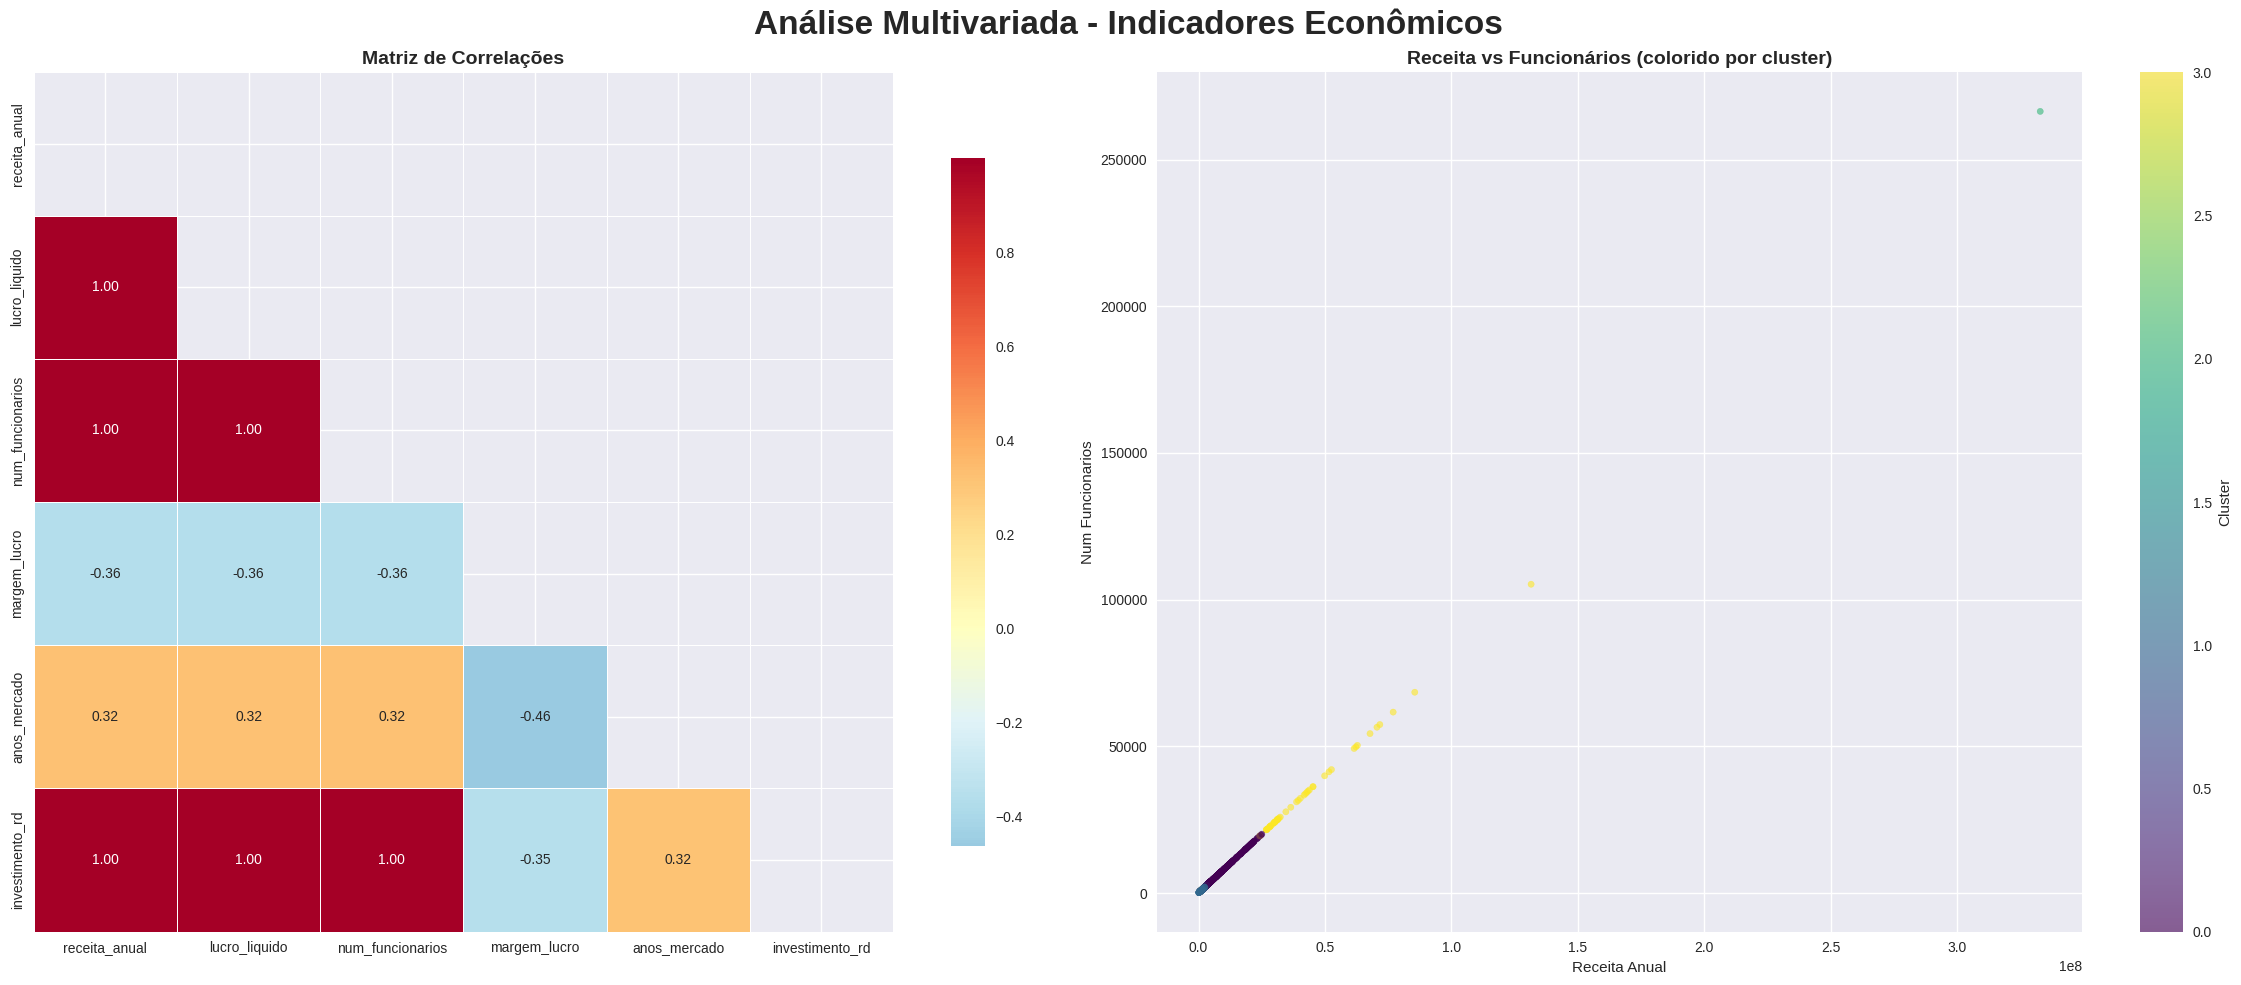

In [28]:
imgs(1)



6. GERANDO VISUALIZAÇÕES MULTIVARIADAS...
--------------------------------------------------


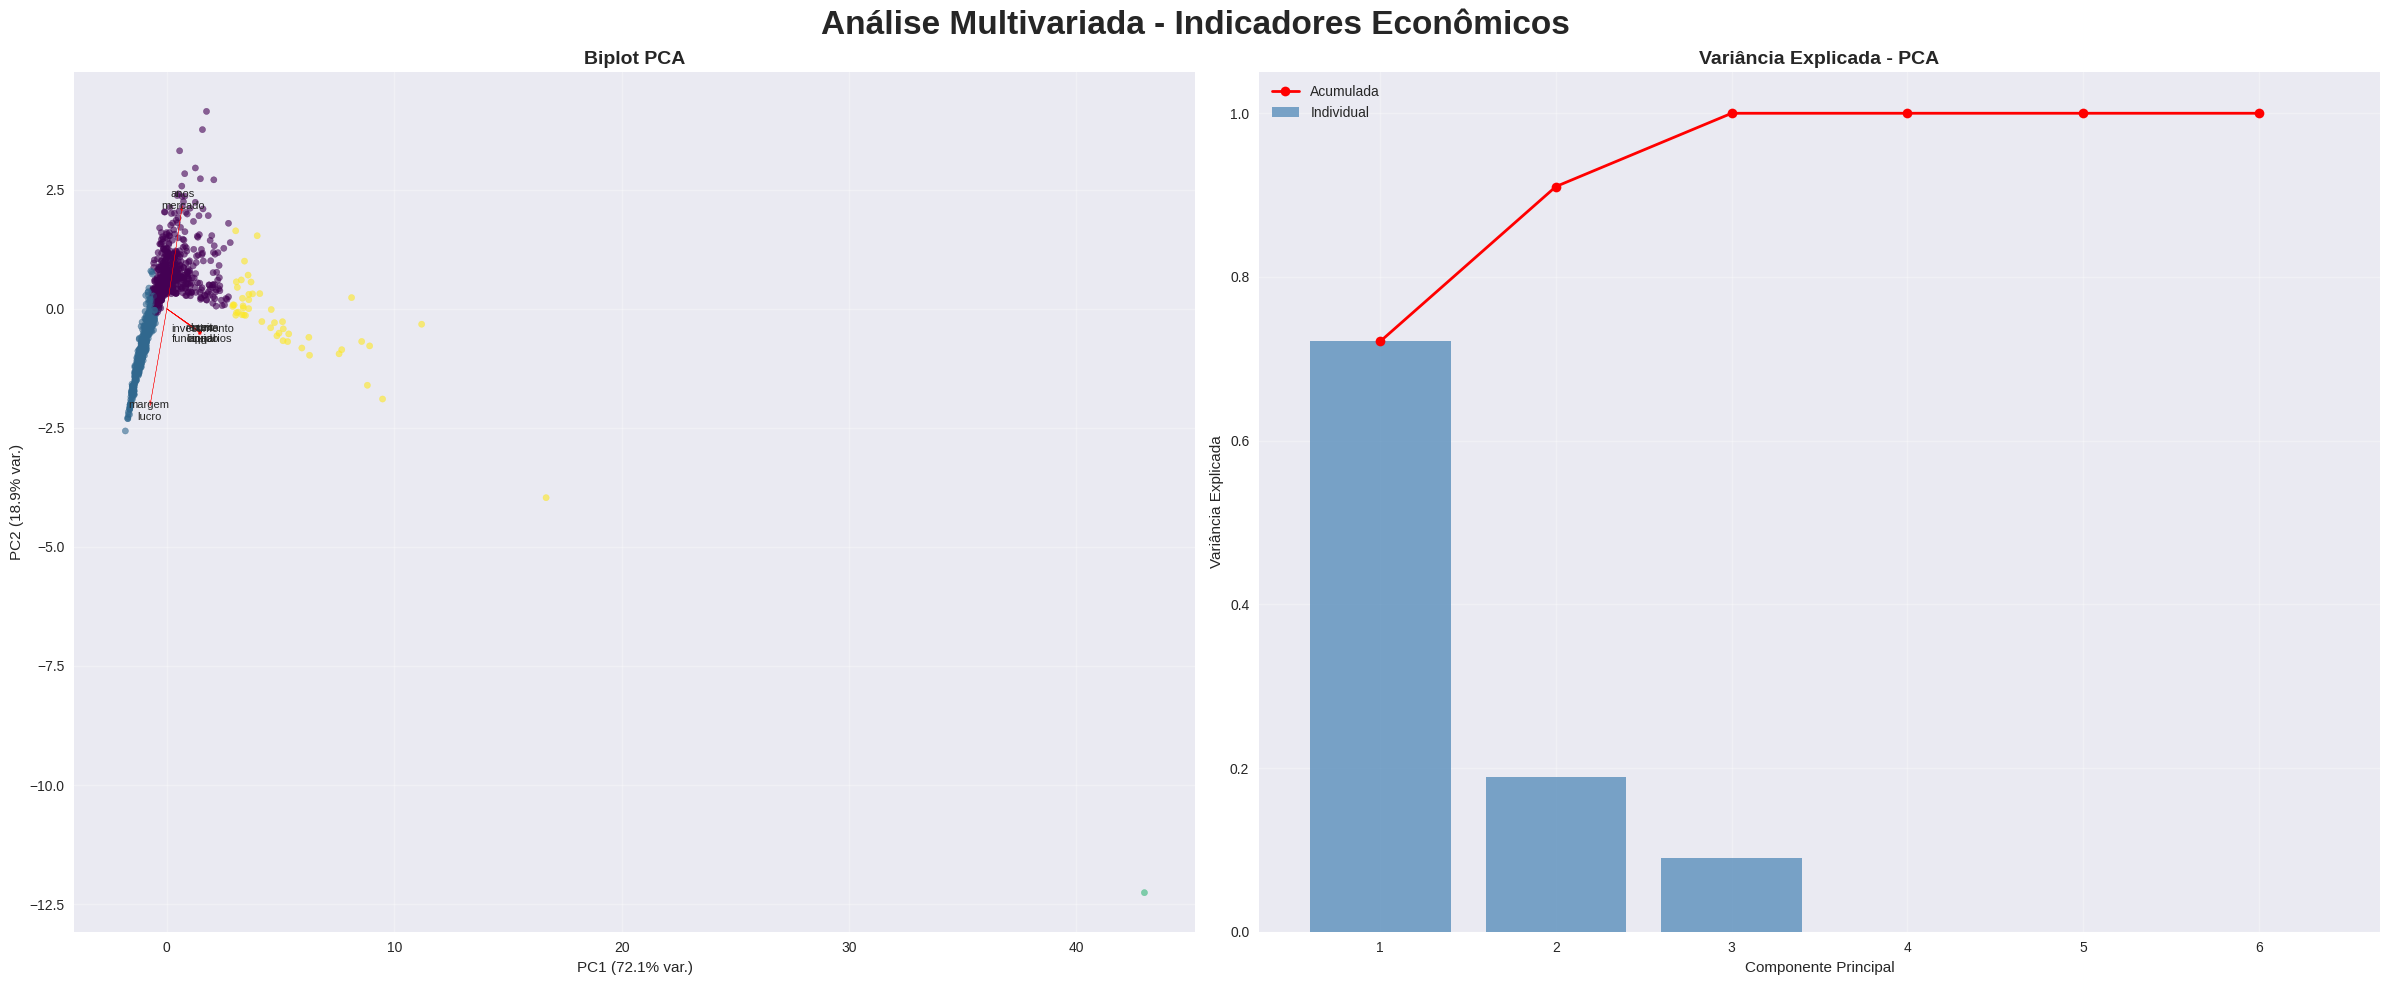

In [29]:
imgs(2)



6. GERANDO VISUALIZAÇÕES MULTIVARIADAS...
--------------------------------------------------


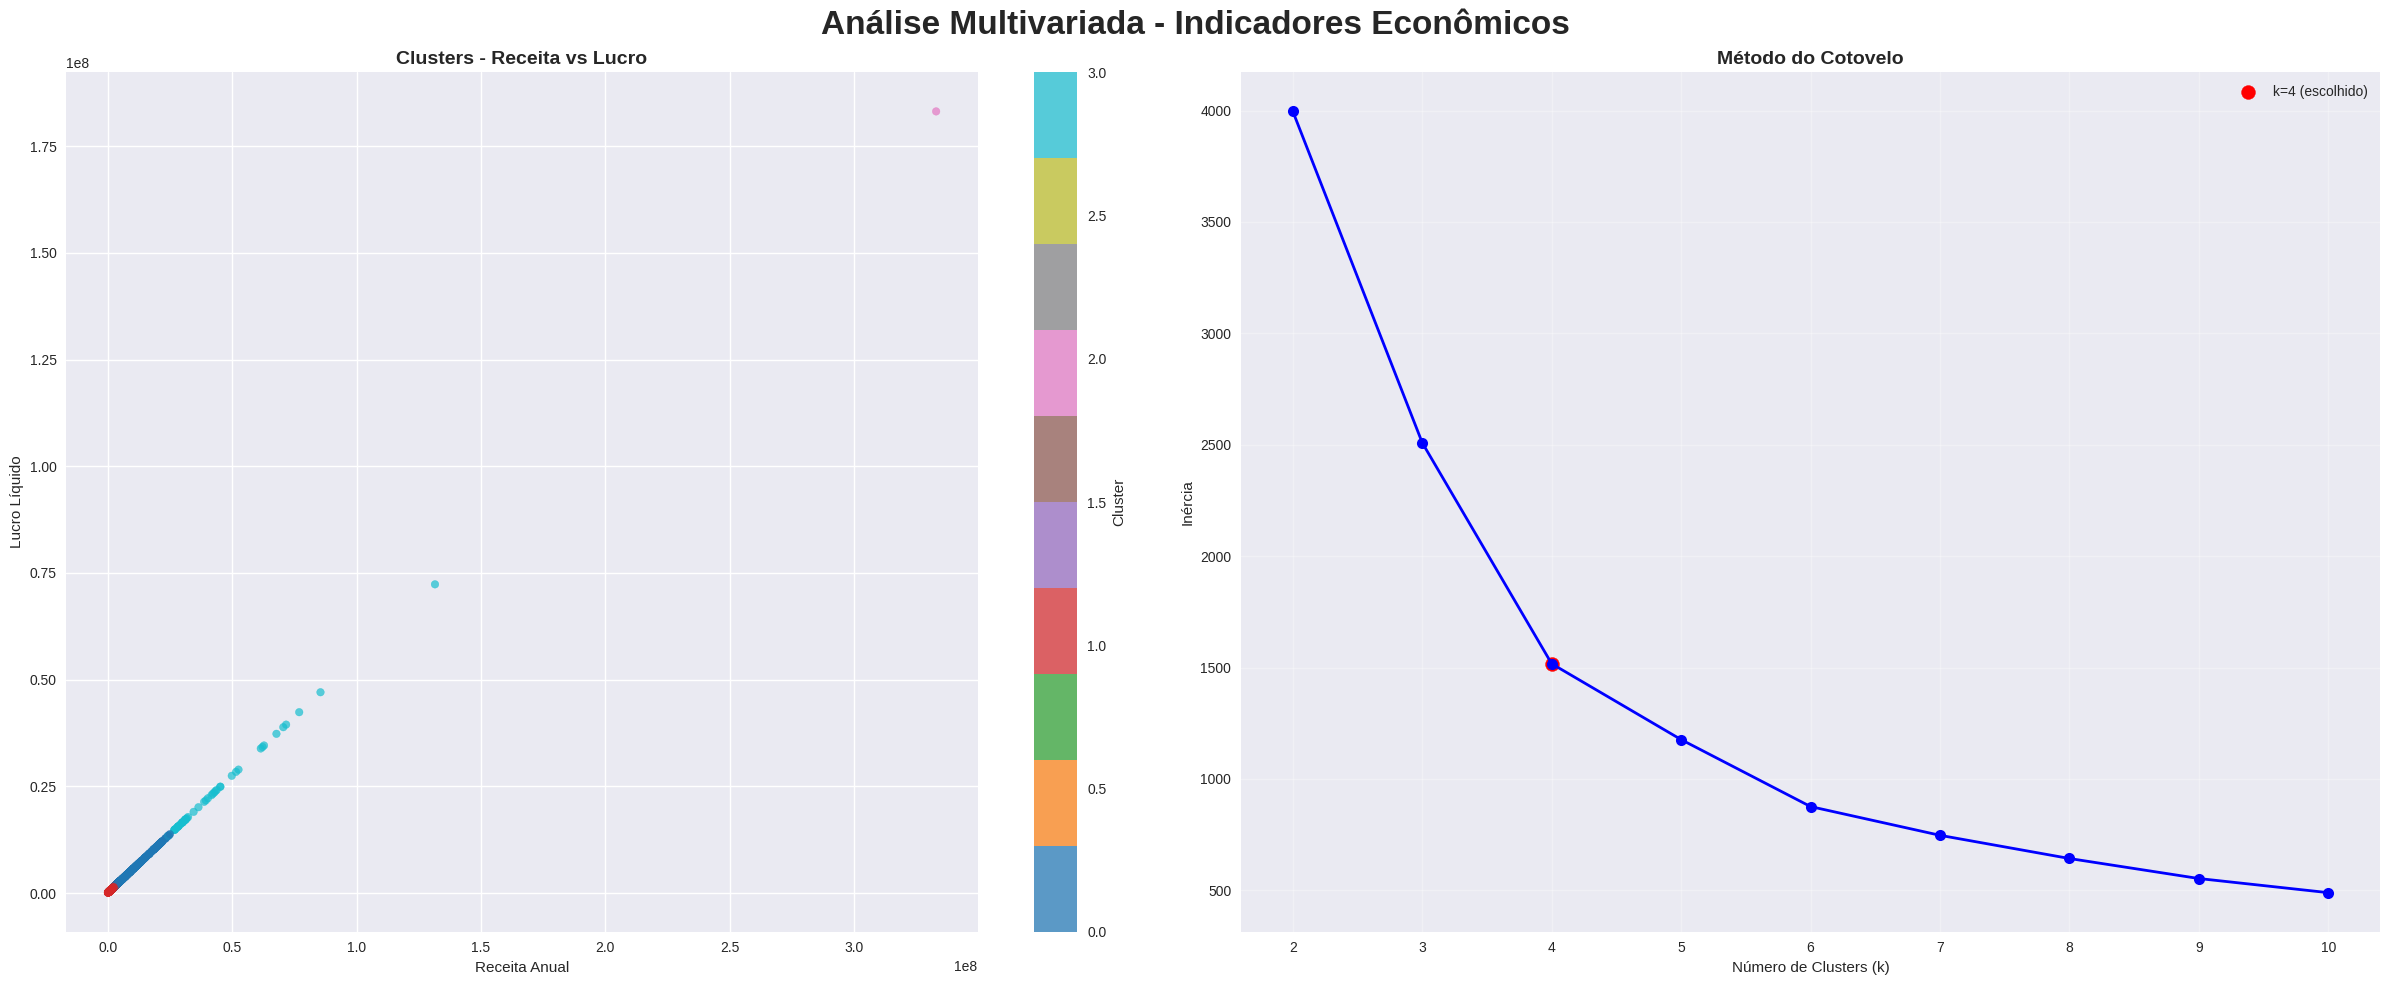

In [30]:
imgs(3)



6. GERANDO VISUALIZAÇÕES MULTIVARIADAS...
--------------------------------------------------


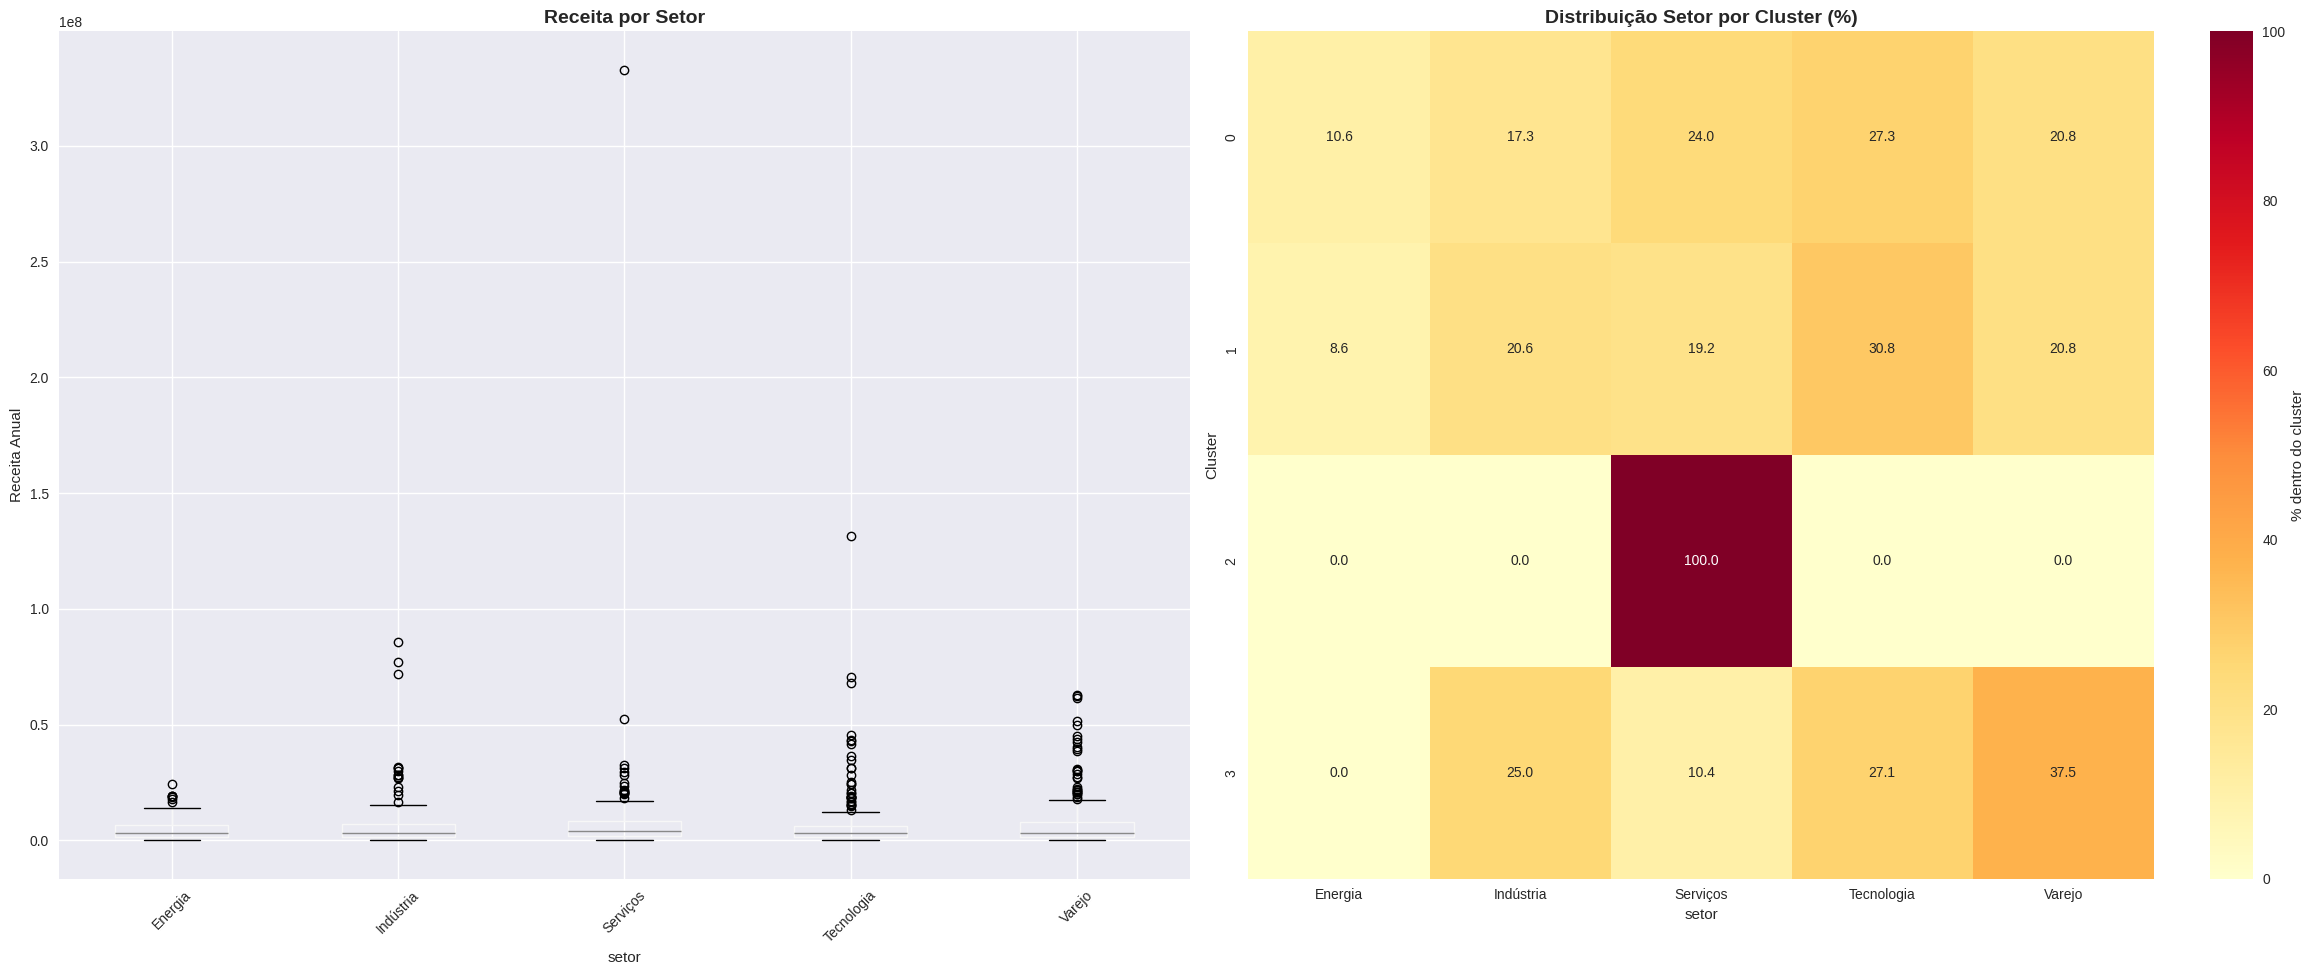

In [31]:
imgs(4)



6. GERANDO VISUALIZAÇÕES MULTIVARIADAS...
--------------------------------------------------


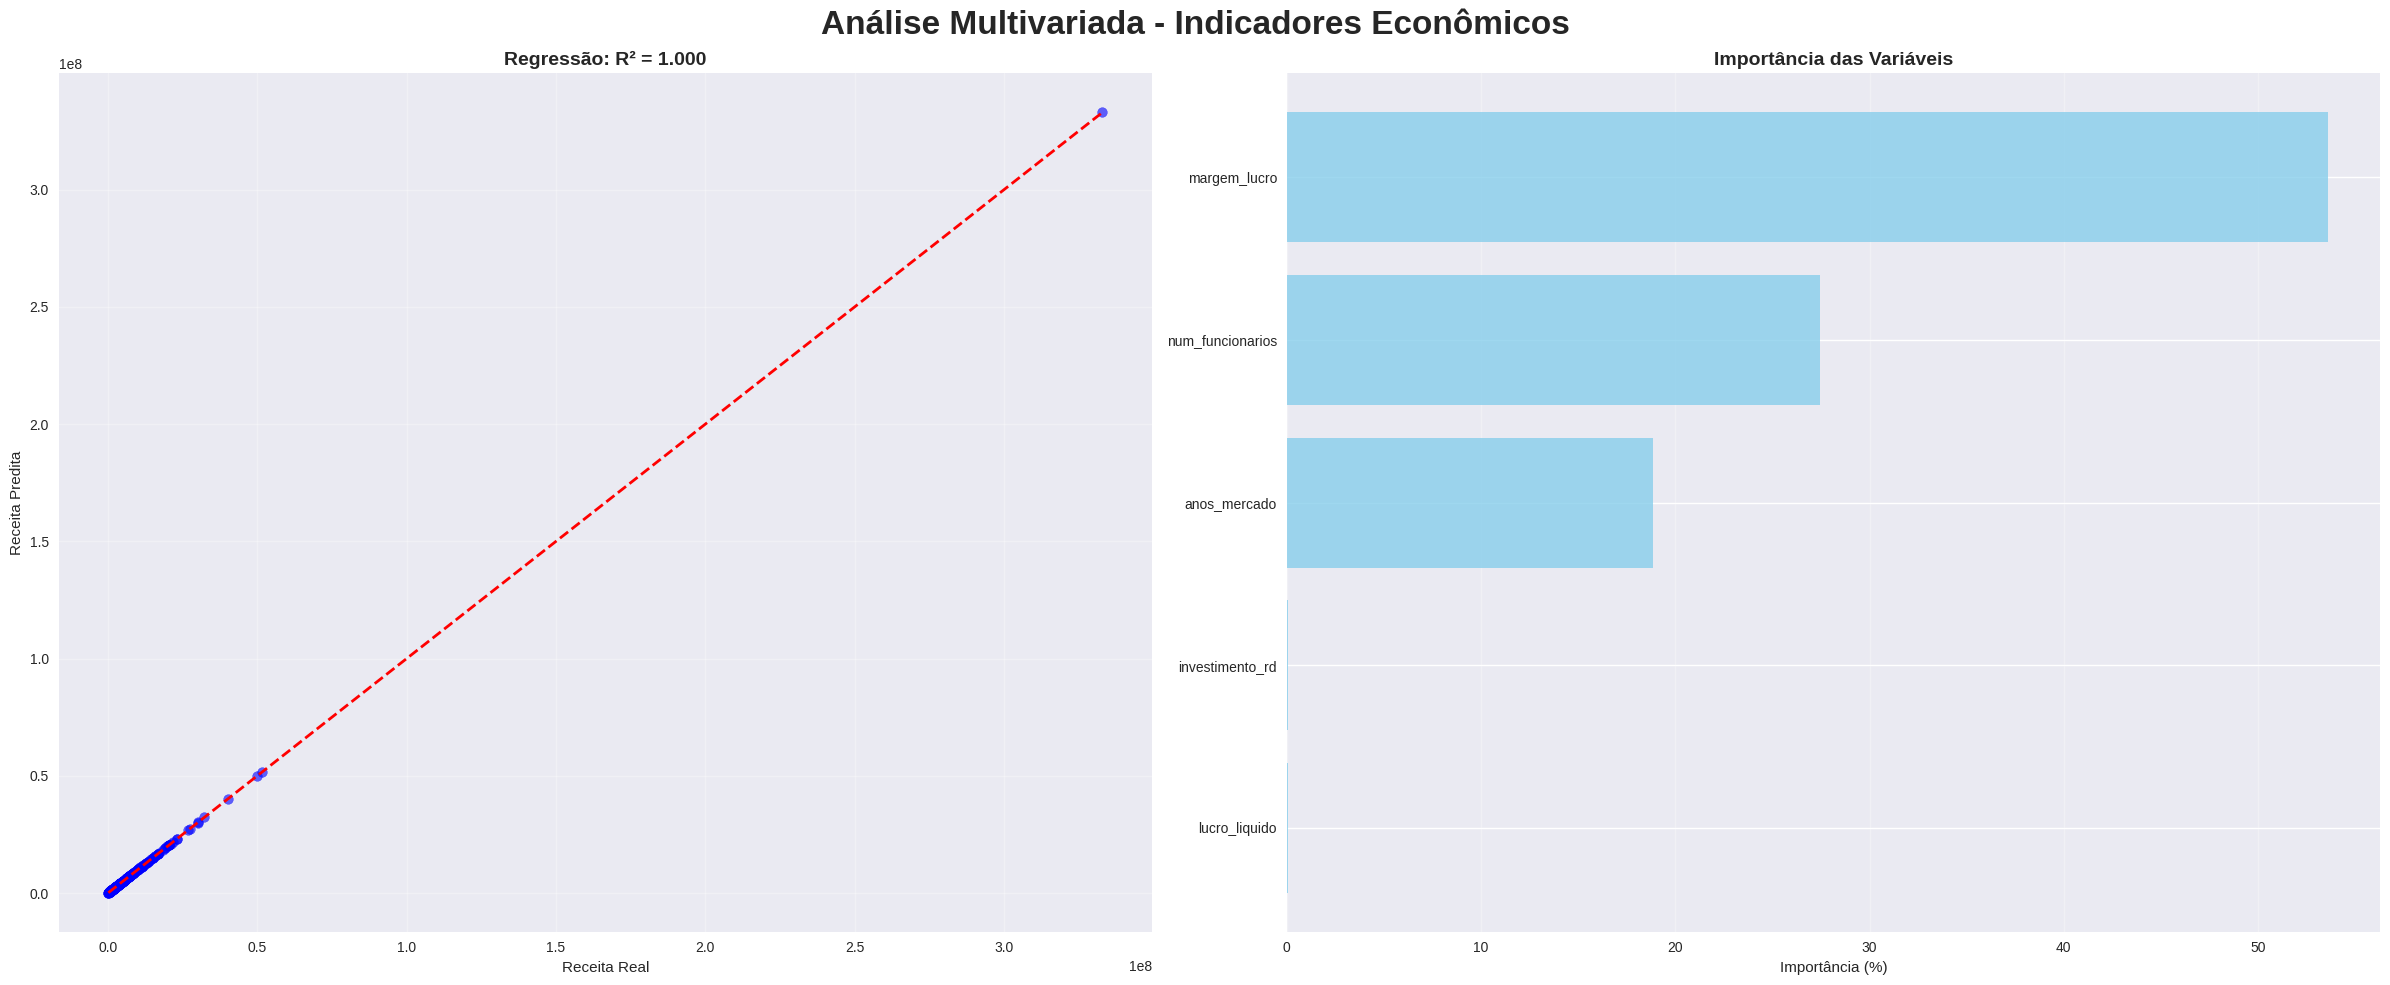

In [32]:
imgs(5)



6. GERANDO VISUALIZAÇÕES MULTIVARIADAS...
--------------------------------------------------


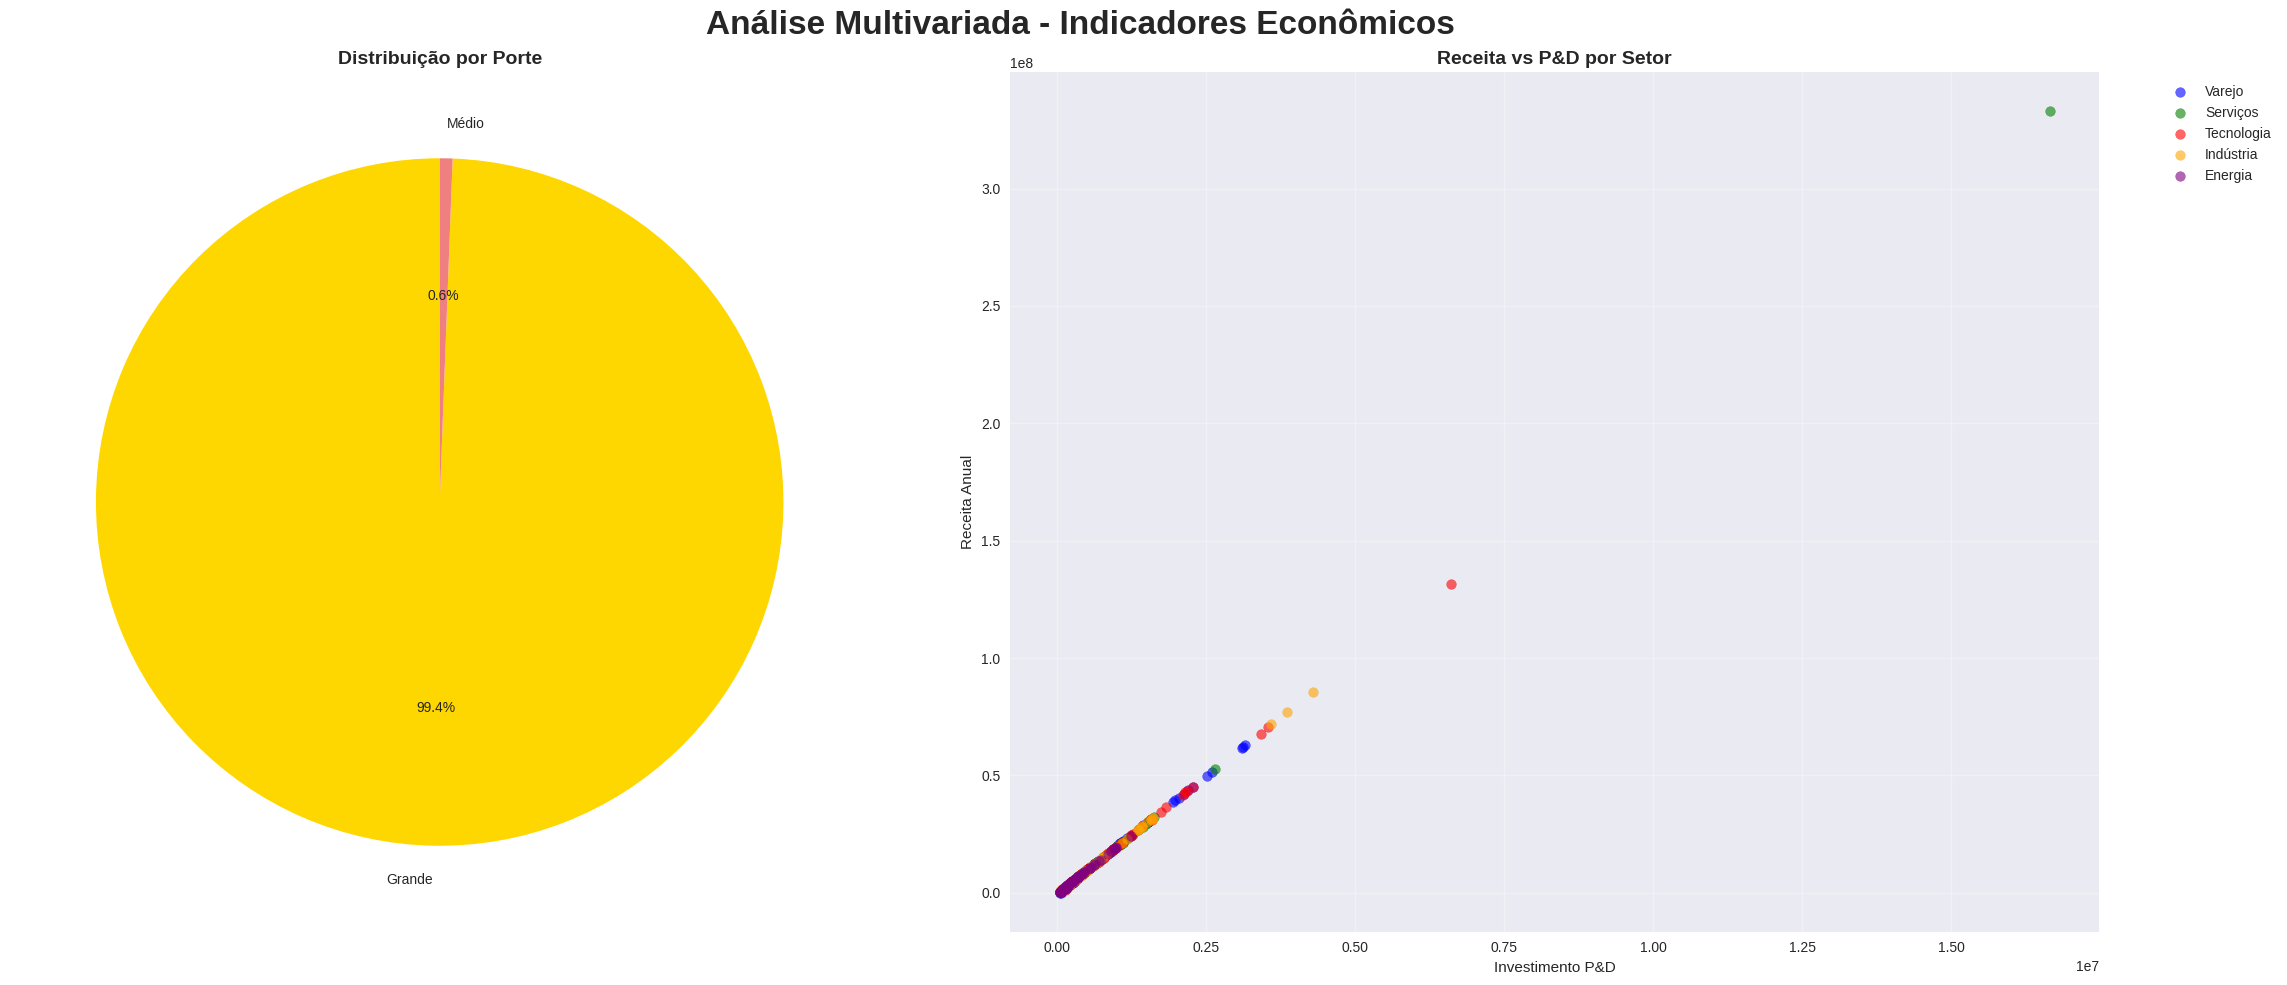

In [33]:
imgs(6)



6. GERANDO VISUALIZAÇÕES MULTIVARIADAS...
--------------------------------------------------


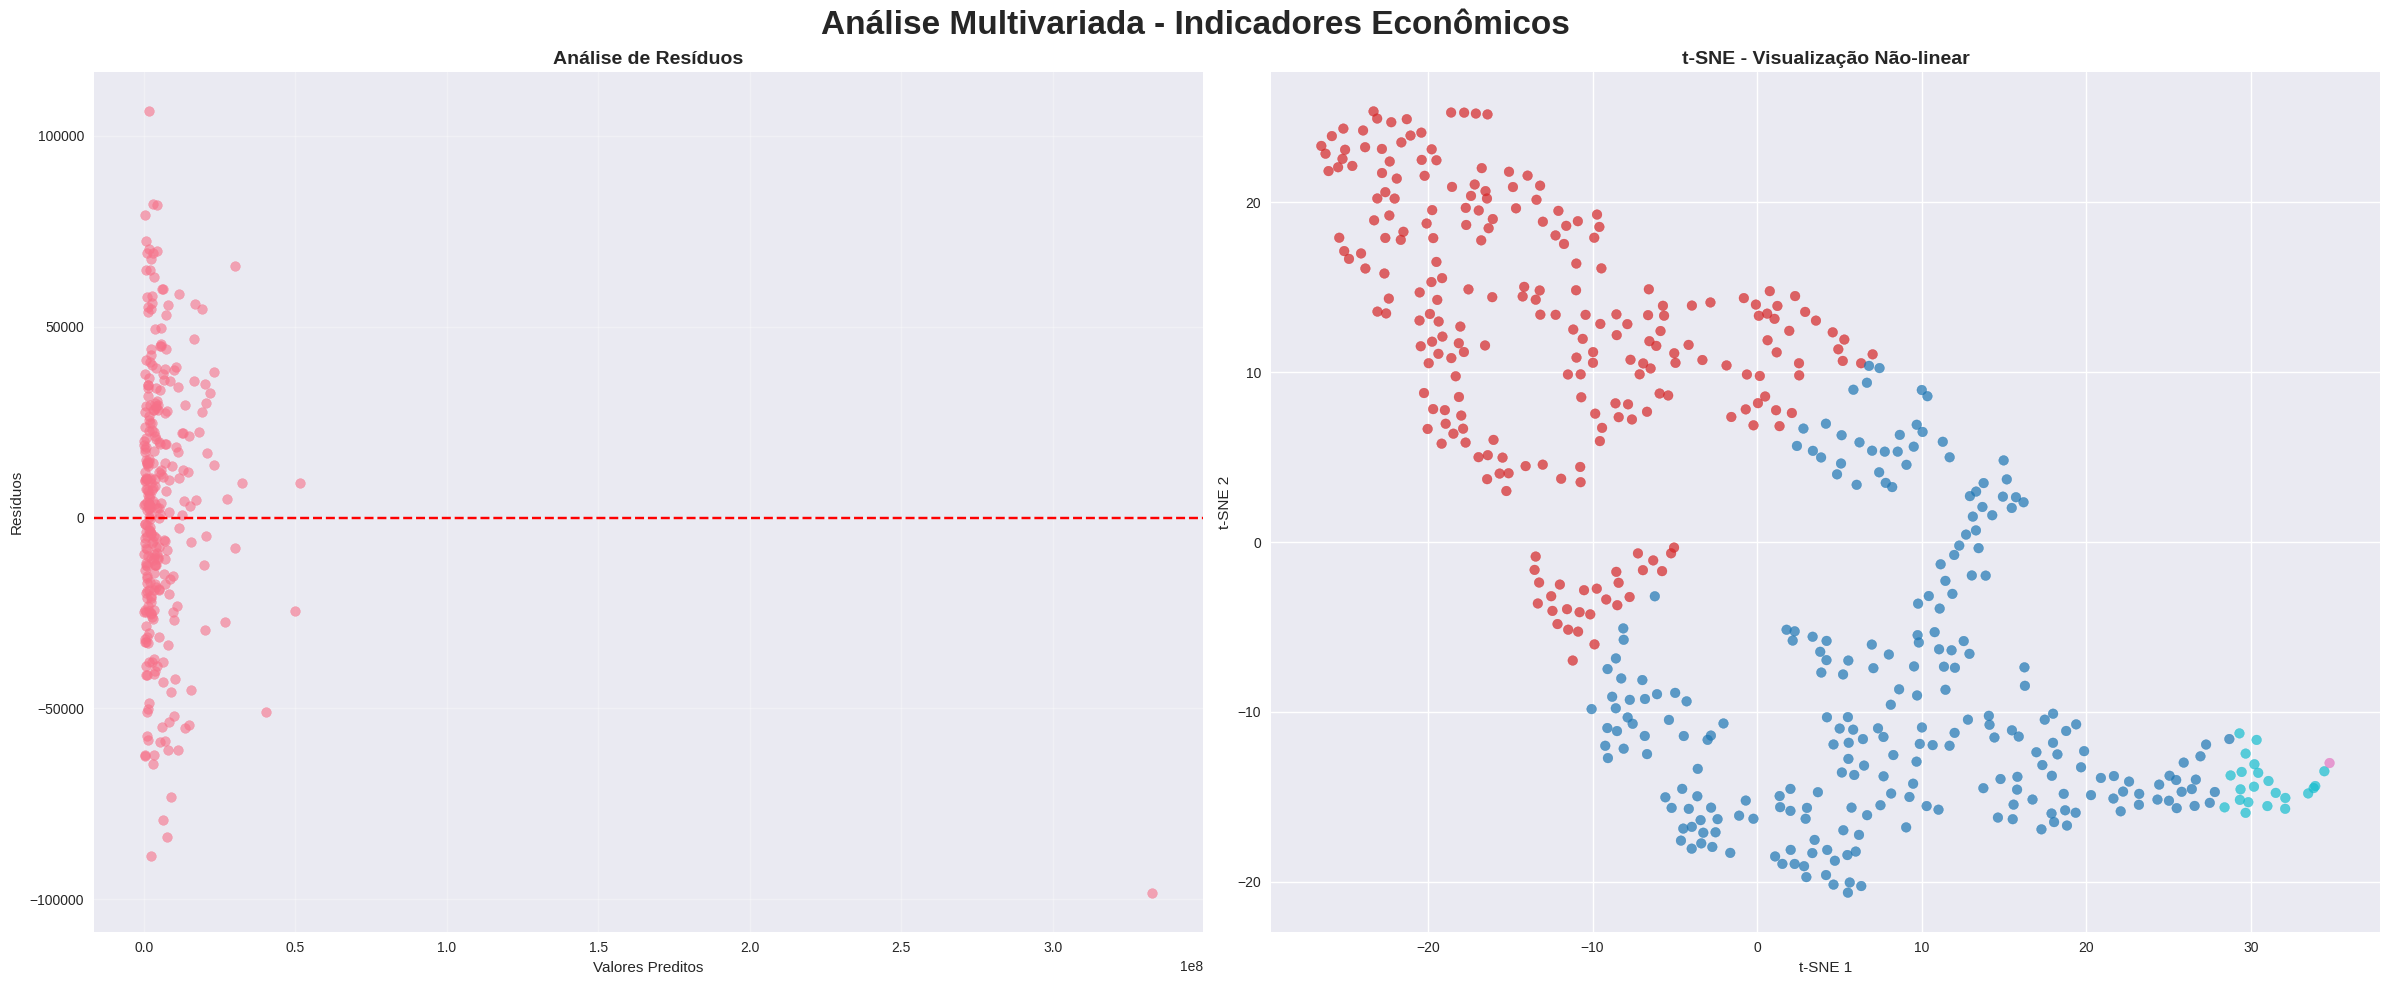

In [34]:
imgs(7)



6. GERANDO VISUALIZAÇÕES MULTIVARIADAS...
--------------------------------------------------


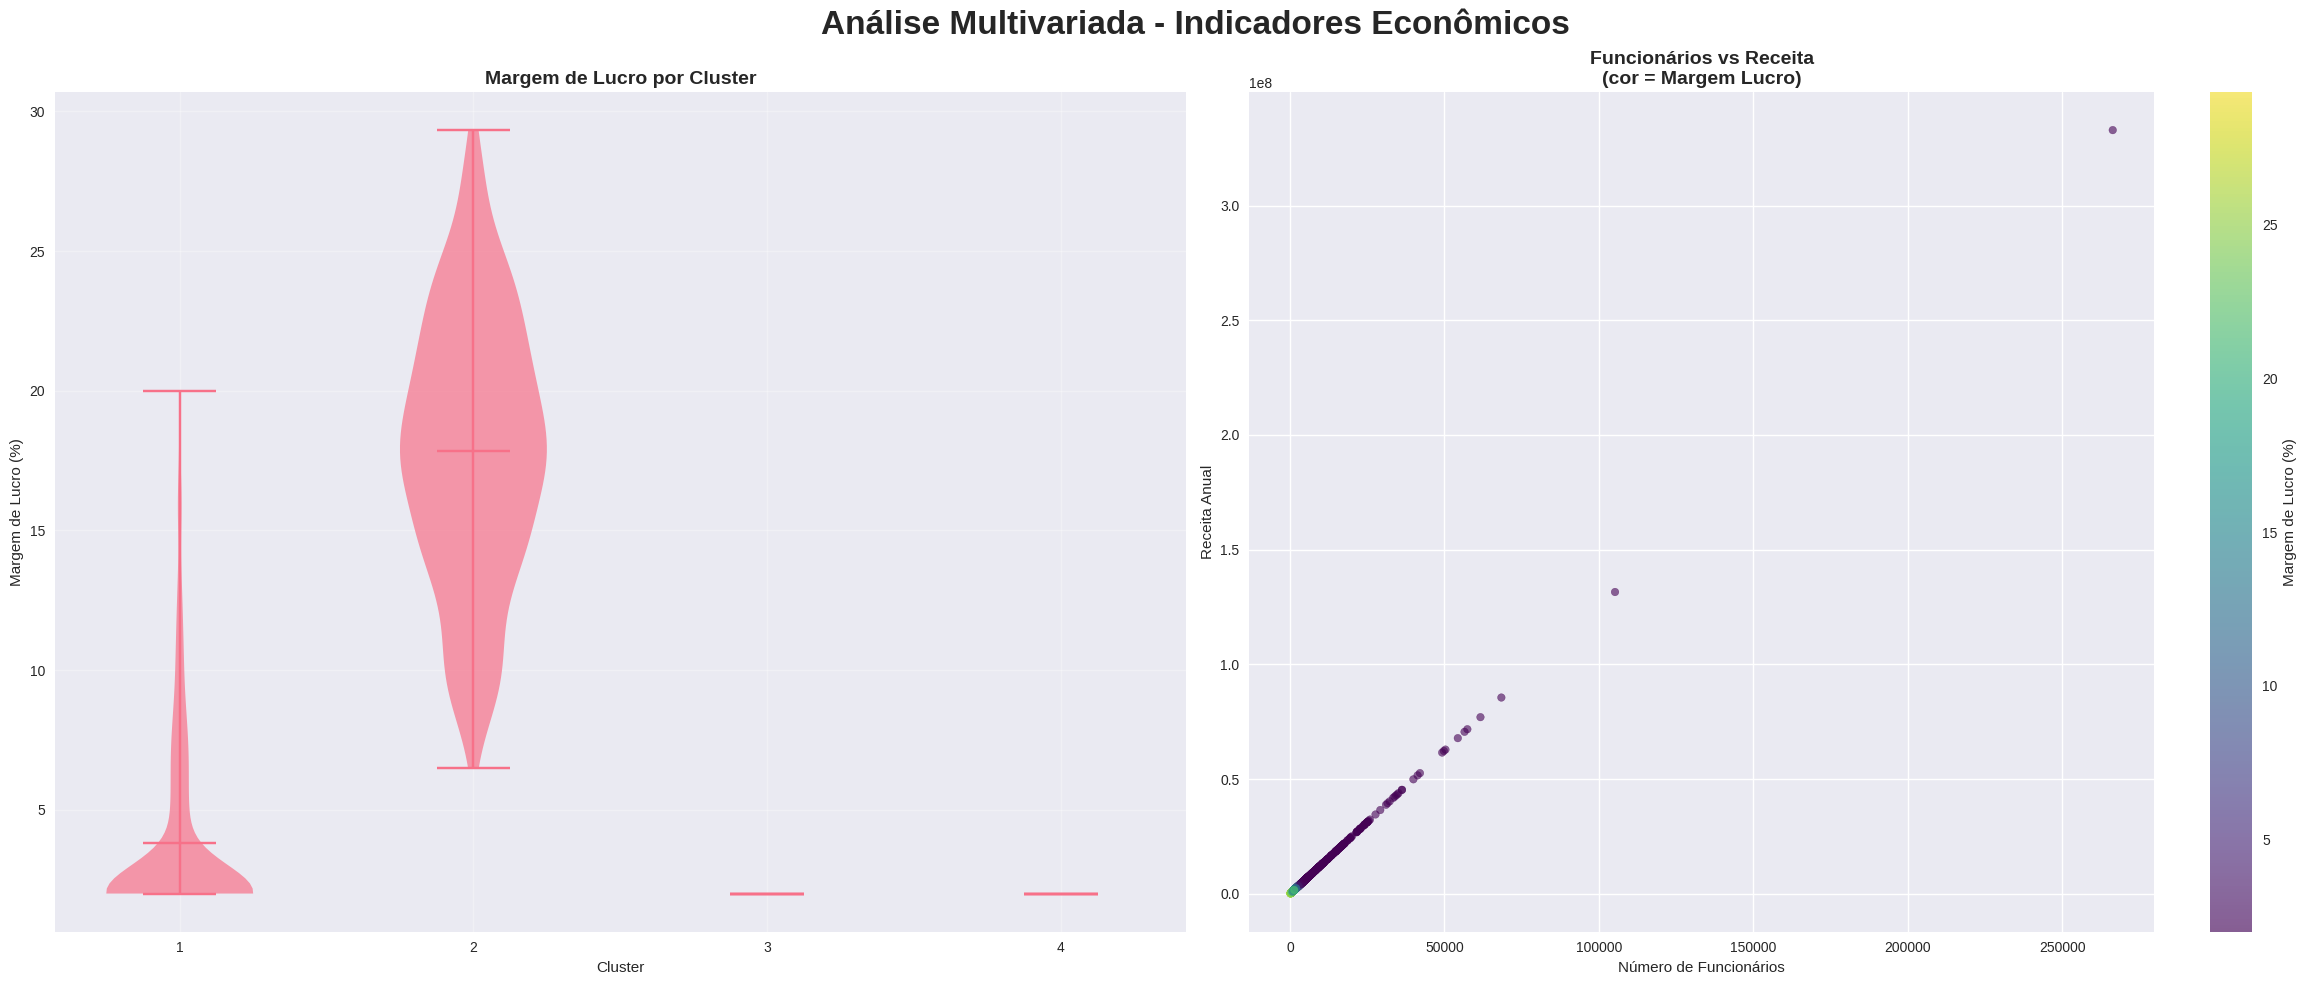

In [35]:
imgs(8)

In [36]:
def resumo():  
    # 8. RESUMO FINAL
    print("\n\n8. RESUMO EXECUTIVO - ANÁLISE MULTIVARIADA")
    print("="*70)

    print("\n🔍 PRINCIPAIS DESCOBERTAS:")

    print(f"\n📊 CORRELAÇÕES:")
    for item in sorted(correlacoes_fortes, key=lambda x: abs(x['correlacao']), reverse=True)[:3]:
        print(f"• {item['var1']} e {item['var2']}: correlação de {item['correlacao']:.3f}")

    print(f"\n🎪 CLUSTERS:")
    print(f"• Identificados {n_clusters} grupos distintos de empresas")
    cluster_mais_rentavel = cluster_stats['margem_lucro'].idxmax()
    print(f"• Cluster {cluster_mais_rentavel + 1} é o mais rentável ({cluster_stats.loc[cluster_mais_rentavel, 'margem_lucro']:.1f}% margem)")

    print(f"\n📈 MODELO PREDITIVO:")
    print(f"• Modelo explica {r2_test*100:.1f}% da variação na receita")
    var_mais_importante_modelo = coef_df.iloc[0]['Variável']
    print(f"• {var_mais_importante_modelo} é a variável mais importante ({coef_df.iloc[0]['Importância']:.1f}%)")

    print(f"\n🏢 ANÁLISE SETORIAL:")
    setor_dominante = df['setor'].value_counts().index[0]
    print(f"• {setor_dominante} é o setor dominante ({df['setor'].value_counts().iloc[0]} empresas)")

    receita_por_setor = df.groupby('setor')['receita_anual'].mean().sort_values(ascending=False)
    setor_maior_receita = receita_por_setor.index[0]
    print(f"• {setor_maior_receita} tem maior receita média (R$ {receita_por_setor.iloc[0]:,.0f})")

In [37]:
resumo()



8. RESUMO EXECUTIVO - ANÁLISE MULTIVARIADA

🔍 PRINCIPAIS DESCOBERTAS:

📊 CORRELAÇÕES:
• lucro_liquido e num_funcionarios: correlação de 1.000
• receita_anual e num_funcionarios: correlação de 1.000
• receita_anual e lucro_liquido: correlação de 1.000

🎪 CLUSTERS:
• Identificados 4 grupos distintos de empresas
• Cluster 2 é o mais rentável (17.9% margem)

📈 MODELO PREDITIVO:
• Modelo explica 100.0% da variação na receita
• margem_lucro é a variável mais importante (53.6%)

🏢 ANÁLISE SETORIAL:
• Tecnologia é o setor dominante (288 empresas)
• Varejo tem maior receita média (R$ 7,905,615)


In [38]:
def insights():
    print(f"\n💡 INSIGHTS ESTRATÉGICOS:")
    print("• Empresas maiores tendem a ter margens menores (economia de escala vs eficiência)")
    print("• Investimento em P&D correlaciona positivamente com receita")
    print("• Clusters revelam perfis empresariais distintos para estratégias direcionadas")
    print("• Modelo permite prever receita com boa precisão usando indicadores operacionais")

In [39]:
insights()


💡 INSIGHTS ESTRATÉGICOS:
• Empresas maiores tendem a ter margens menores (economia de escala vs eficiência)
• Investimento em P&D correlaciona positivamente com receita
• Clusters revelam perfis empresariais distintos para estratégias direcionadas
• Modelo permite prever receita com boa precisão usando indicadores operacionais


## Objetivos e importância de uma análise exploratória de dados bem feita

Uma base de dados, quando submetida a uma análise, pode conter diferentes
problemas, como dados ausentes (missing values), valores discrepantes, valores truncados, dados corrompidos ou dados incompletos.

| Linha | ID  | Rua                | Nº   | Alocada | Quartos | Banheiros | Observações                     |
|-------|-----|--------------------|------|---------|---------|-----------|---------------------------------|
| 1     | 100 |                    | 21   | Sim     | 3       | 2         | Rua ausente                     |
| 2     | 200 | Rua João Vicente   | 33   | **222** | 4       | 3         | Valor corrompido em "Alocada"  |
| 3     | 300 | Av João da Silva V | 567  | Não     | 1       | 1         | -                               |


## Identificando outliers

Um outlier é um valor que foge da normalidade e
que pode (e provavelmente irá) causar anomalias nos resultados obtidos por meio de algoritmos e sistemas de análise. 

| Linha | Código | Nome completo                | Idade | Último salário | Observações               |
|-------|--------|-------------------------------|--------|----------------|----------------------------|
| 1     | 201    | Antonio Nunes                | 64     |                |                            |
| 2     | 202    | Maria da Silva               | 71     |                |                            |
| 3     | 203    | Pedro Antunes de Oliveira    | 59     |                |                            |
| 4     | 204    | João da Silva                | **475**|                | Outlier na coluna "Idade" |


## Resolvendo problemas no pré-processamento

Para alguns algorítmos de **Aprendizado de Máquina** ou **Redes Neurais**, uma etapa extra de pré-processamento deve ser levada em consideração. Essa etapa é chamada de **NORMALIZAÇÃO**, **ESCALONAMENTO** ou **PADRONIZAÇÃO** das variáveis

- Reescalonar significa alterar a unidade de medida dos dados, convertendo em determinada proporção

- Normalização significa dividir por uma norma do vetor, por exemplo, subtrair dados do vetor menor e dividir pela subtração do valor máximo e valor mínimo, assim colocando os dados em uma faixa de 0 a 1.

- A padronização trata de subtrair os dados por uma medição de localização e dividir por uma média de escala, permitindo deixar os dados mais próximos da medida normal, possível.

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler, Normalizer

def ex_sc():
    # 1. Criar um conjunto de dados pequeno e simples
    # Usamos .reshape(-1, 1) porque os scalers do scikit-learn esperam dados 2D (amostras, recursos)
    data = np.array([0.2, 1.3, 3.8, 2.15, 4.20], dtype=float).reshape(-1, 1)

    # 2. Aplicar Reescalonamento (Min-Max Scaling)
    min_max_scaler = MinMaxScaler()
    data_rescaled = min_max_scaler.fit_transform(data)

    # 3. Aplicar Padronização (Standardization)
    standard_scaler = StandardScaler()
    data_standardized = standard_scaler.fit_transform(data)

    # 4. Aplicar Normalização (L2 Normalization)
    # A normalização age nas linhas (amostras). Para ver o efeito em nosso vetor,
    # precisamos transpor os dados para que cada valor seja uma "amostra"
    normalizer = Normalizer()
    data_normalized = normalizer.fit_transform(data.T).T # Transpõe, normaliza e transpõe de volta

    # 6. Criar o gráfico para visualização
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(12, 6))

    # Define as posições no eixo y para cada conjunto de dados para melhor visualização
    y_positions = {
        "Original": 4,
        "Reescalonado (Min-Max)": 3,
        "Padronizado (Z-score)": 2,
        "Normalizado (L2)": 1
    }

    # Plota cada conjunto de dados como uma linha de pontos
    ax.scatter(data, [y_positions["Original"]] * len(data), label="Original", s=100, color='black')
    ax.scatter(data_rescaled, [y_positions["Reescalonado (Min-Max)"]] * len(data), label="Reescalonado (Min-Max)", s=100)
    ax.scatter(data_standardized, [y_positions["Padronizado (Z-score)"]] * len(data), label="Padronizado", s=100)
    ax.scatter(data_normalized, [y_positions["Normalizado (L2)"]] * len(data), label="Normalizado (L2)", s=100)

    # Configurações do gráfico para clareza
    ax.set_yticks(list(y_positions.values()))
    ax.set_yticklabels(list(y_positions.keys()))
    ax.set_xlabel("Valor do Ponto de Dado", fontsize=12)
    ax.set_title("Comparação Visual de Técnicas de Escalonamento de Dados", fontsize=16)
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.tight_layout()

    # Salva a figura para que possa ser visualizada
    plt.savefig("comparacao_escalonamento_visual.png")

    print("\nGráfico 'comparacao_escalonamento_visual.png' foi salvo no diretório.")


Gráfico 'comparacao_escalonamento_visual.png' foi salvo no diretório.


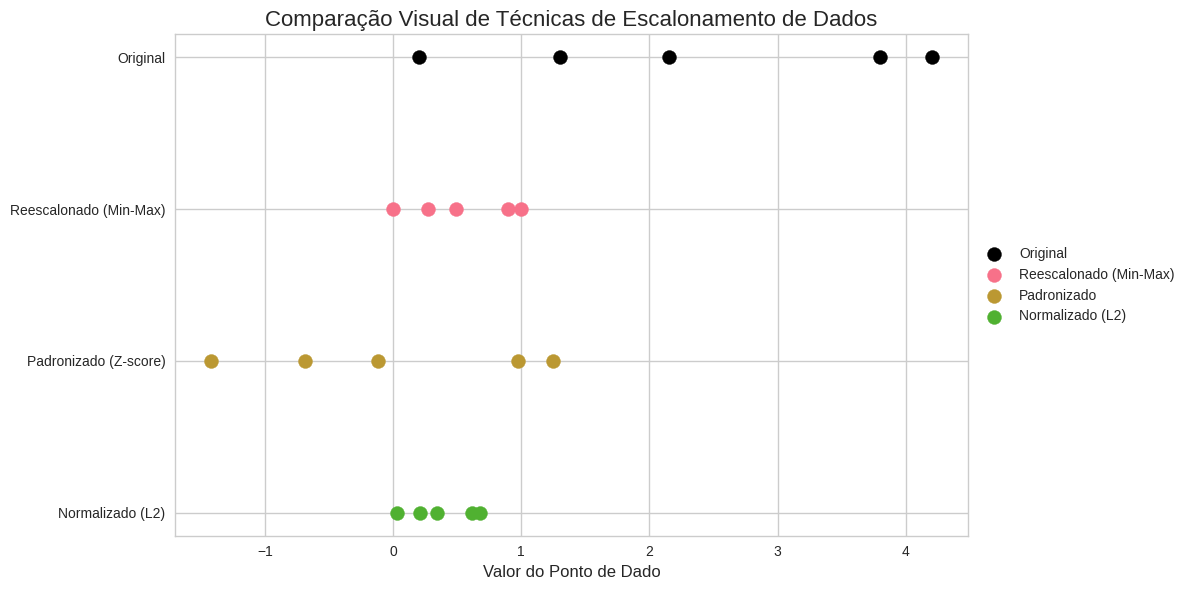

In [41]:
ex_sc()

In [44]:
def ex_sc2():
    import numpy as np
    import pandas as pd
    import seaborn as sns
    import matplotlib.pyplot as plt
    from sklearn.datasets import load_iris
    from sklearn.preprocessing import MinMaxScaler, StandardScaler, Normalizer

    # 1. Carregar o dataset Iris
    iris = load_iris()
    # Criar um DataFrame do pandas para facilitar a manipulação
    iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

    # 2. Selecionar um recurso para o nosso exemplo
    # Usaremos 'sepal width (cm)' e o transformaremos em um array 2D para os scalers
    feature_name = 'petal width (cm)'
    data_iris = iris_df[[feature_name]].values # .values converte para array numpy

    # --- Aplicação das Técnicas de Escalonamento ---

    # 3. Reescalonamento (Min-Max Scaling)
    min_max_scaler = MinMaxScaler()
    data_rescaled = min_max_scaler.fit_transform(data_iris)

    # 4. Padronização (Standardization)
    standard_scaler = StandardScaler()
    data_standardized = standard_scaler.fit_transform(data_iris)

    # 5. Normalização (L2 Normalization)
    # Note: Isso é feito aqui para demonstração, mas lembre-se que age nas amostras.
    # Como temos apenas um recurso, o resultado da normalização L2 será trivial (cada valor dividido por ele mesmo, resultando em 1.0)
    # Para um exemplo mais útil de normalização, precisaríamos de múltiplos recursos por amostra.
    normalizer = Normalizer()
    data_normalized = normalizer.fit_transform(data_iris)

    # --- Visualização ---

    # 6. Criar um gráfico de densidade para comparar as distribuições
    plt.figure(figsize=(14, 7))
    sns.kdeplot(data_iris.flatten(), fill=True, label='Original', lw=3)
    sns.kdeplot(data_rescaled.flatten(), fill=True, label='Reescalonado (Min-Max)', lw=3)
    sns.kdeplot(data_standardized.flatten(), fill=True, label='Padronizado (Z-score)', lw=3)

    plt.title(f'Distribuição de "{feature_name}" Após Escalonamento', fontsize=16)
    plt.xlabel('Valores do Recurso', fontsize=12)
    plt.ylabel('Densidade', fontsize=12)
    plt.legend()
    plt.grid(True)
    plt.savefig("iris_scaling_comparison.png")

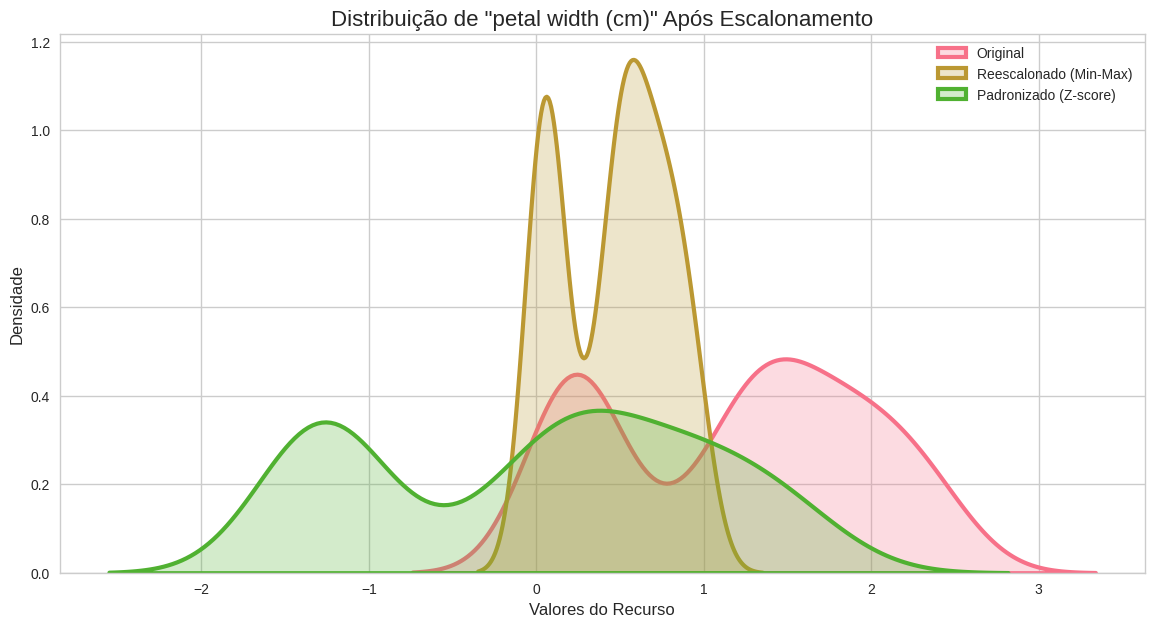

In [45]:
ex_sc2()